# **1. Import Libraries**


* Pandas → Data manipulation and analysis
* NumPy → Numerical operations
* Matplotlib → Data visualization

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# **2. Load Dataset**

In [4]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Define the correct dataset path
dataset1_path = "/content/drive/MyDrive/Smart_Home_Energy_Project/dataset1_smart_home_energy_consumption.csv"

# Load Dataset 1
df1 = pd.read_csv(dataset1_path)
df1_original = df1.copy()

# Display the first 5 rows
df1.head()

Mounted at /content/drive


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


# **3. Dataset Overview & Data Quality**

We will examine:
*   Dataset dimensions
*   Column names
*   Data types
*   Missing values
*   Duplicate records
*   List itemBasic sample of the data

In [5]:
# Dataset overview and basic data quality

print("Dataset shape:")
print(df1.shape)

print("\nDataset information:")
df1.info()

print("\nMissing values:")
print(df1.isnull().sum())

print("\nExact duplicate rows:")
print(df1.duplicated().sum())

Dataset shape:
(100000, 8)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB

Missing values:
Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                 

# **4. Understanding the Variables**

In [6]:
# Summary statistics for numerical variables
print("Numerical variables summary:")
print(df1.describe())

# Check the unique appliance types
print("\nAppliance types:")
print(df1["Appliance Type"].value_counts())

# Check the unique seasons
print("\nSeasons:")
print(df1["Season"].value_counts())

Numerical variables summary:
             Home ID  Energy Consumption (kWh)  Outdoor Temperature (°C)  \
count  100000.000000             100000.000000             100000.000000   
mean      250.374980                  1.499952                 14.950135   
std       144.435367                  1.181176                 14.438755   
min         1.000000                  0.100000                -10.000000   
25%       125.000000                  0.590000                  2.400000   
50%       250.000000                  1.230000                 14.900000   
75%       375.000000                  1.870000                 27.400000   
max       500.000000                  5.000000                 40.000000   

       Household Size  
count   100000.000000  
mean         3.001770  
std          1.417077  
min          1.000000  
25%          2.000000  
50%          3.000000  
75%          4.000000  
max          5.000000  

Appliance types:
Appliance Type
Lights              10201
Dishwasher 

## 5. Exploring Energy Consumption

In [7]:
# Statistical summary of energy consumption
print("Energy Consumption statistics:")
print(df1["Energy Consumption (kWh)"].describe())

# Check the most common energy consumption values
print("\nEnergy Consumption value counts:")
print(df1["Energy Consumption (kWh)"].value_counts().head(10))

Energy Consumption statistics:
count    100000.000000
mean          1.499952
std           1.181176
min           0.100000
25%           0.590000
50%           1.230000
75%           1.870000
max           5.000000
Name: Energy Consumption (kWh), dtype: float64

Energy Consumption value counts:
Energy Consumption (kWh)
0.47    688
0.34    686
0.36    679
0.28    671
0.27    670
0.21    667
0.26    660
0.41    658
0.48    655
0.44    645
Name: count, dtype: int64


# **6. Histogram**
A histogram shows the distribution of numerical values across different ranges.

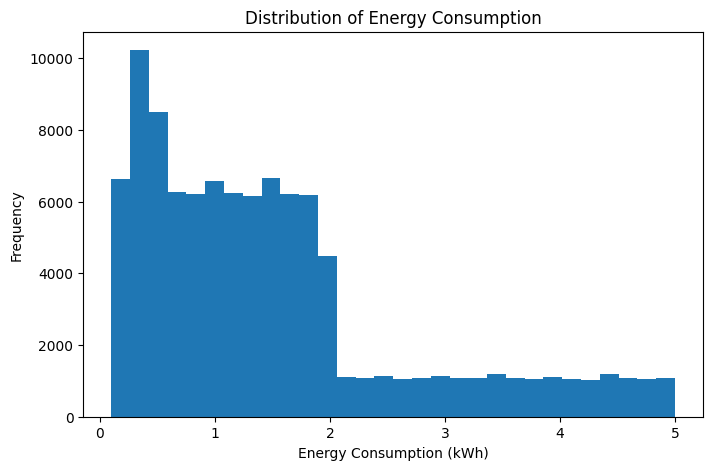

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df1["Energy Consumption (kWh)"], bins=30)
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.title("Distribution of Energy Consumption")
plt.show()

# **7. Exploring Energy Consumption**

In [9]:
# Plot average energy consumption by appliance type
appliance_mean = (
    df1.groupby("Appliance Type")["Energy Consumption (kWh)"]
    .mean()
    .sort_values(ascending=False)
)
print("Average energy consumption by Appliance Type")
print(appliance_mean)

Average energy consumption by Appliance Type
Appliance Type
Air Conditioning    3.499857
Heater              3.486802
Dishwasher          1.103369
Oven                1.103080
Washing Machine     1.101412
Microwave           1.100961
TV                  1.097221
Computer            1.095498
Lights              1.087356
Fridge              0.298255
Name: Energy Consumption (kWh), dtype: float64


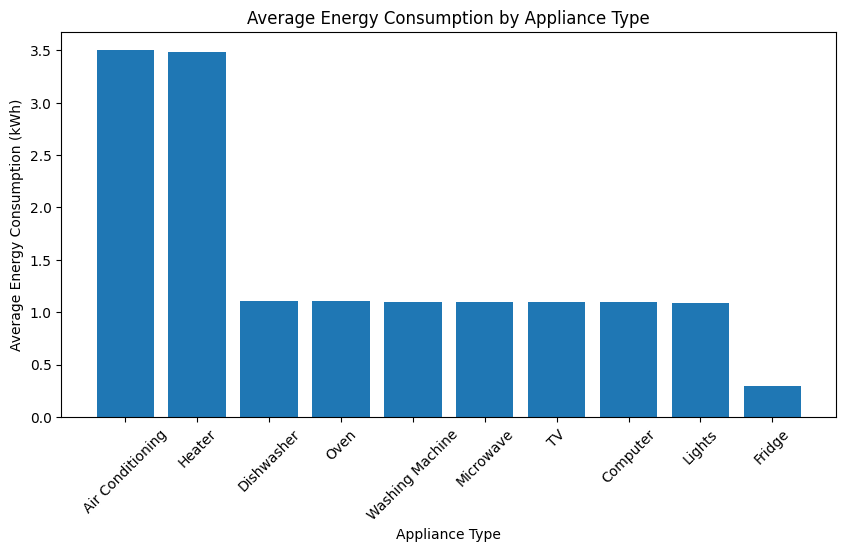

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(appliance_mean.index, appliance_mean.values)
plt.xlabel("Appliance Type")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Appliance Type")
plt.xticks(rotation=45)
plt.show()

Average energy consumption by season:
Season
Fall      1.497545
Spring    1.510863
Summer    1.495173
Winter    1.496156
Name: Energy Consumption (kWh), dtype: float64


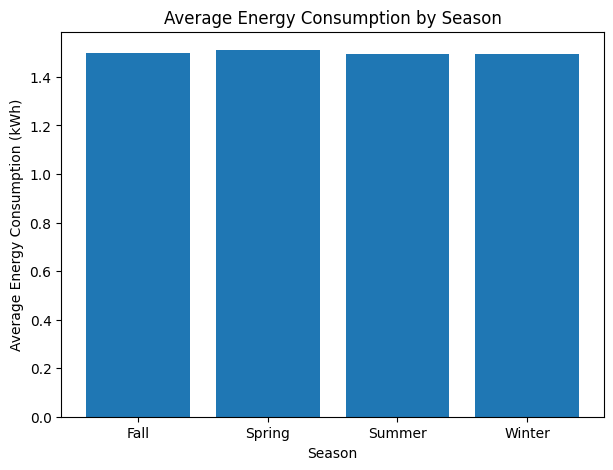

In [11]:
# Average energy consumption by season
season_mean = (
    df1.groupby("Season")["Energy Consumption (kWh)"]
    .mean()
)
print("Average energy consumption by season:")
print(season_mean)

# Plot average energy consumption by season
plt.figure(figsize=(7, 5))
plt.bar(season_mean.index, season_mean.values)
plt.xlabel("Season")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Season")
plt.show()

Average energy consumption by household size:
Household Size
1    1.507659
2    1.513151
3    1.490346
4    1.503494
5    1.485319
Name: Energy Consumption (kWh), dtype: float64


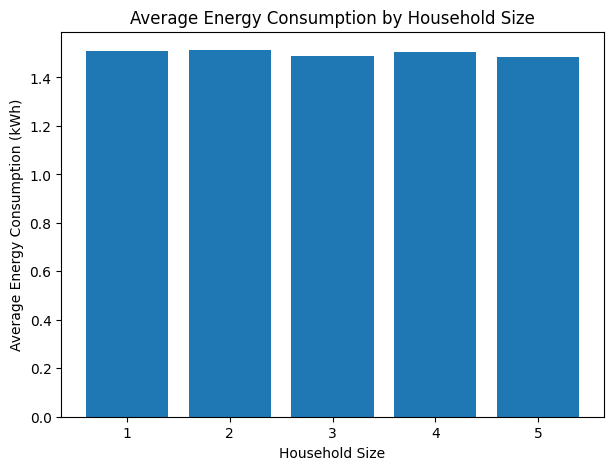

In [12]:
# Average energy consumption by household size
household_mean = (
    df1.groupby("Household Size")["Energy Consumption (kWh)"]
    .mean()
)

print("Average energy consumption by household size:")
print(household_mean)

# Plot average energy consumption by household size
plt.figure(figsize=(7, 5))
plt.bar(household_mean.index, household_mean.values)
plt.xlabel("Household Size")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Household Size")
plt.show()

## 8. Environmental & Time Patterns

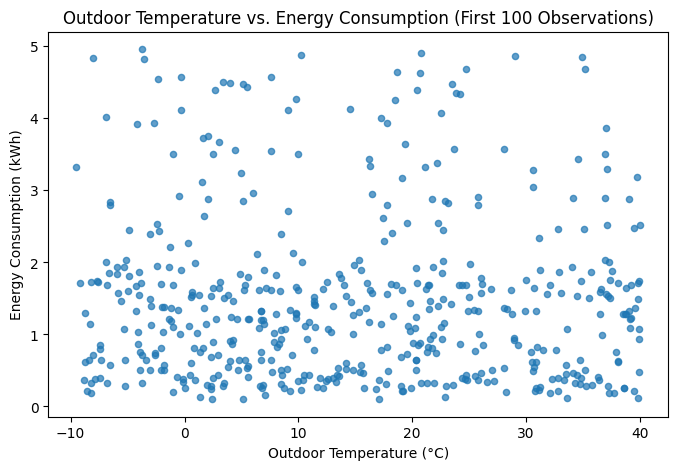

Correlation between temperature and energy consumption:
0.001994633640609449


In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df1["Outdoor Temperature (°C)"].head(500),
    df1["Energy Consumption (kWh)"].head(500),
    s=20,
    alpha=0.7
)

plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Outdoor Temperature vs. Energy Consumption (First 100 Observations)")
plt.show()

# Calculate the correlation between outdoor temperature and energy consumption
correlation = df1["Outdoor Temperature (°C)"].corr(
    df1["Energy Consumption (kWh)"] 
)

print("Correlation between temperature and energy consumption:")
print(correlation)

# **9. Time-of-Day Analysis**

Unique time values:
['21:12' '20:11' '06:39' ... '05:51' '04:36' '05:54']

Number of unique time values:
1440
Average energy consumption by hour:
Hour
0     1.511212
1     1.516715
2     1.493072
3     1.506133
4     1.501015
5     1.492647
6     1.498498
7     1.507834
8     1.511865
9     1.523713
10    1.479208
11    1.488706
12    1.493882
13    1.497608
14    1.538801
15    1.493915
16    1.488523
17    1.524689
18    1.479130
19    1.488460
20    1.488275
21    1.476048
22    1.531600
23    1.469778
Name: Energy Consumption (kWh), dtype: float64


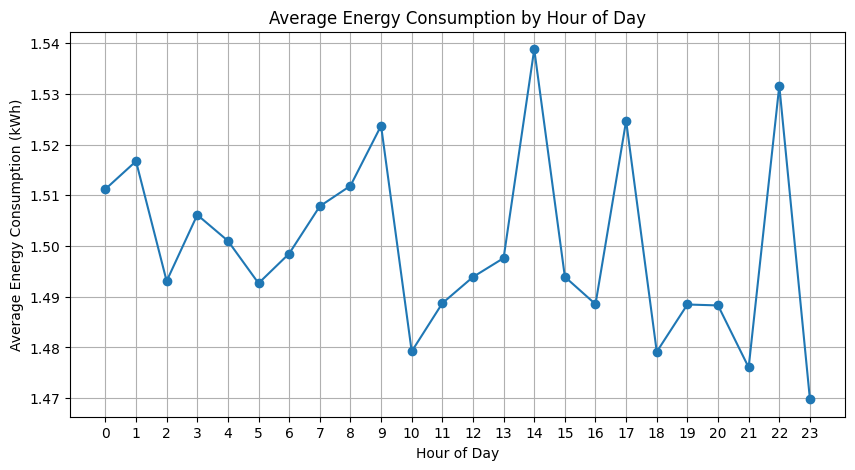

In [14]:
# Check the time values in the dataset
print("Unique time values:")
print(df1["Time"].unique())

print("\nNumber of unique time values:")
print(df1["Time"].nunique())

# Analyze average energy consumption by hour of the day

time_data = pd.to_datetime(df1["Time"], format="%H:%M")

hourly_mean = (
    df1.assign(Hour=time_data.dt.hour)
    .groupby("Hour")["Energy Consumption (kWh)"]
    .mean()
)

print("Average energy consumption by hour:")
print(hourly_mean)

# Plot average energy consumption by hour

plt.figure(figsize=(10, 5))

plt.plot(hourly_mean.index, hourly_mean.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Hour of Day")
plt.xticks(range(24))
plt.grid()
plt.show()

# **10. Monthly Energy Pattern**

Earliest date:
2023-01-01

Latest date:
2024-01-01

Number of unique dates:
366
Average energy consumption by month:
Month
1     1.512982
2     1.490529
3     1.483752
4     1.514678
5     1.511567
6     1.506362
7     1.495822
8     1.500065
9     1.489485
10    1.491571
11    1.506736
12    1.494715
Name: Energy Consumption (kWh), dtype: float64


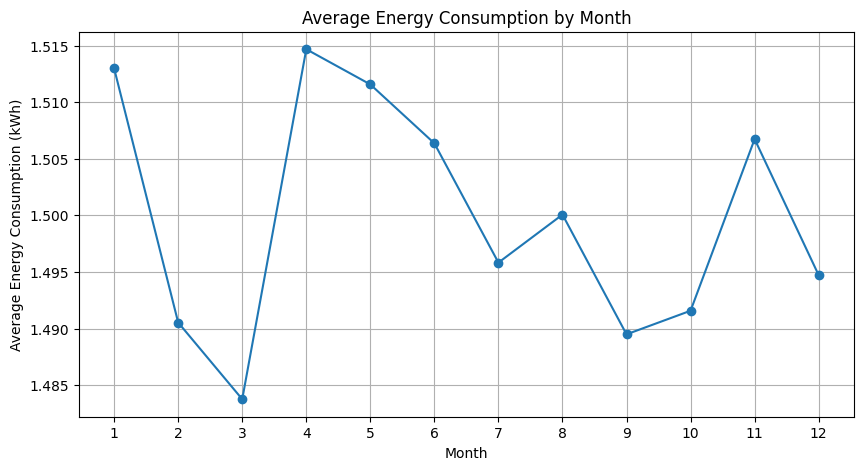

In [15]:
# Check the date range in the dataset

print("Earliest date:")
print(df1["Date"].min())

print("\nLatest date:")
print(df1["Date"].max())

print("\nNumber of unique dates:")
print(df1["Date"].nunique())

# Analyze average energy consumption by month

date_data = pd.to_datetime(df1["Date"])

monthly_mean = (
    df1.assign(Month=date_data.dt.month)
    .groupby("Month")["Energy Consumption (kWh)"]
    .mean()
)

print("Average energy consumption by month:")
print(monthly_mean)

# Plot average energy consumption by month

plt.figure(figsize=(10, 5))

plt.plot(monthly_mean.index, monthly_mean.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Month")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

# **11. Correlation Analysis**

Correlation Matrix:
                          Energy Consumption (kWh)  Outdoor Temperature (°C)  \
Energy Consumption (kWh)                  1.000000                  0.001995   
Outdoor Temperature (°C)                  0.001995                  1.000000   
Household Size                           -0.006501                 -0.005145   

                          Household Size  
Energy Consumption (kWh)       -0.006501  
Outdoor Temperature (°C)       -0.005145  
Household Size                  1.000000  


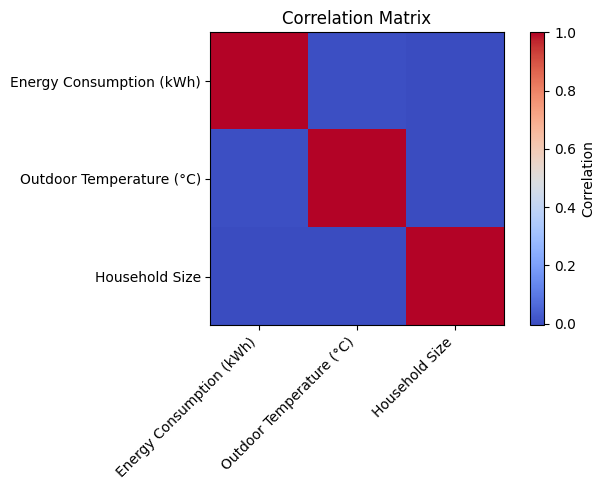

In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# **12. Outlier Investigation**

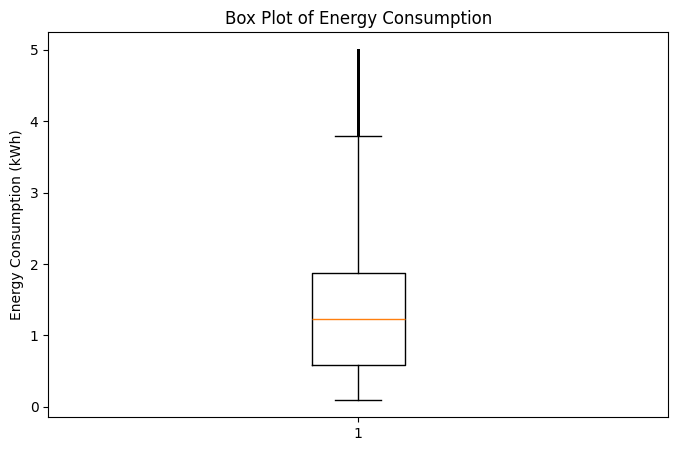

Q1: 0.59
Q3: 1.87
IQR: 1.2800000000000002

Lower bound: -1.3300000000000005
Upper bound: 3.7900000000000005

Number of potential outliers: 7997
Percentage of potential outliers: 7.997
Energy consumption statistics by appliance:
                      mean  max
Appliance Type                 
Air Conditioning  3.499857  5.0
Heater            3.486802  5.0
Dishwasher        1.103369  2.0
Oven              1.103080  2.0
Washing Machine   1.101412  2.0
Microwave         1.100961  2.0
TV                1.097221  2.0
Computer          1.095498  2.0
Lights            1.087356  2.0
Fridge            0.298255  0.5


<Figure size 1200x600 with 0 Axes>

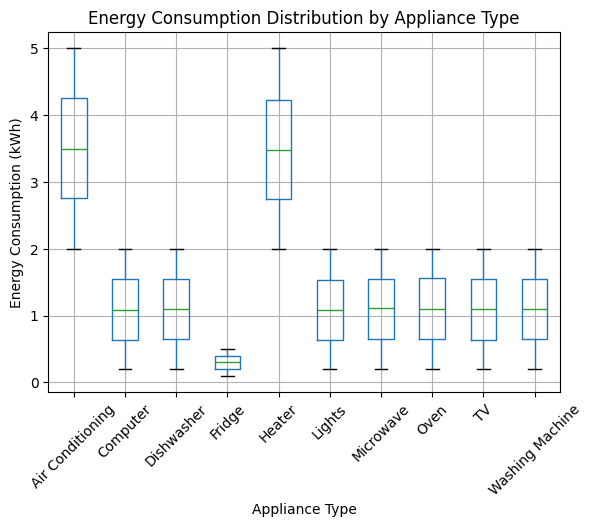

In [17]:
# Visualize energy consumption using a box plot

plt.figure(figsize=(8, 5))

plt.boxplot(df1["Energy Consumption (kWh)"] ,
    flierprops=dict(marker=".", markersize=2)
            )

plt.ylabel("Energy Consumption (kWh)")
plt.title("Box Plot of Energy Consumption")

plt.show()

# Detect potential outliers using the IQR method

Q1 = df1["Energy Consumption (kWh)"].quantile(0.25)
Q3 = df1["Energy Consumption (kWh)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df1[
    (df1["Energy Consumption (kWh)"] < lower_bound) |
    (df1["Energy Consumption (kWh)"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of potential outliers:", len(outliers))
print("Percentage of potential outliers:", len(outliers) / len(df1) * 100)

# Compare average energy consumption with maximum consumption by appliance

appliance_stats = (
    df1.groupby("Appliance Type")["Energy Consumption (kWh)"]
    .agg(["mean", "max"])
    .sort_values("mean", ascending=False)
)

print("Energy consumption statistics by appliance:")
print(appliance_stats)

# Visualize energy consumption distribution by appliance type

plt.figure(figsize=(12, 6))

df1.boxplot(
    column="Energy Consumption (kWh)",
    by="Appliance Type",
    rot=45
)

plt.xlabel("Appliance Type")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Energy Consumption Distribution by Appliance Type")
plt.suptitle("")

plt.show()

# Dataset 2 — Smart Home Energy Usage

This dataset is used as a supporting dataset for exploring household energy usage behavior, appliance usage duration, occupancy status, and environmental context.

# Load Dataset 2

In [18]:
# Define Dataset 2 Path
dataset2_path = "/content/drive/MyDrive/Smart_Home_Energy_Project/dataset2_smart_home_energy_usage.csv"

# Load Dataset 2
df2 = pd.read_csv(dataset2_path)
df2_original = df2.copy()

# Display first 5 rows
df2.head()

,timestamp,home_id,energy_consumption_kWh,temperature_setting_C,occupancy_status,appliance,usage_duration_minutes,season,day_of_week,holiday
0,2023-01-01 00:00:00,44,2.87,22.1,Occupied,Refrigerator,111,Spring,Sunday,0
1,2023-01-01 01:00:00,81,0.56,15.4,Occupied,HVAC,103,Summer,Sunday,0
2,2023-01-01 02:00:00,94,4.49,22.4,Occupied,Electronics,12,Autumn,Sunday,0
3,2023-01-01 03:00:00,20,2.13,24.6,Unoccupied,Dishwasher,54,Autumn,Sunday,0
4,2023-01-01 04:00:00,3,2.74,21.4,Unoccupied,HVAC,6,Summer,Sunday,0


## 1. Dataset Overview & Data Quality

In [19]:
print("Dataset shape:")
print(df2.shape)

print("\nDataset information:")
df2.info()

print("\nMissing values:")
print(df2.isnull().sum())

print("\nExact duplicate rows:")
print(df2.duplicated().sum())

Dataset shape:
(1000000, 10)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1000000 non-null  object 
 1   home_id                 1000000 non-null  int64  
 2   energy_consumption_kWh  1000000 non-null  float64
 3   temperature_setting_C   1000000 non-null  float64
 4   occupancy_status        1000000 non-null  object 
 5   appliance               1000000 non-null  object 
 6   usage_duration_minutes  1000000 non-null  int64  
 7   season                  1000000 non-null  object 
 8   day_of_week             1000000 non-null  object 
 9   holiday                 1000000 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 76.3+ MB

Missing values:
timestamp                 0
home_id                   0
energy_consumption_kWh    0
temperature_s

# 2. Understanding the Variables

In [20]:
# Summary statistics for numerical variables
print("Numerical variables summary:")
print(df2.describe())

# Check occupancy status
print("\nOccupancy status:")
print(df2["occupancy_status"].value_counts())

# Check appliance categories
print("\nAppliance categories:")
print(df2["appliance"].value_counts())

# Check seasons
print("\nSeasons:")
print(df2["season"].value_counts())

# Check days of the week
print("\nDays of the week:")
print(df2["day_of_week"].value_counts())

# Check holiday values
print("\nHoliday values:")
print(df2["holiday"].value_counts())

Numerical variables summary:
              home_id  energy_consumption_kWh  temperature_setting_C  \
count  1000000.000000          1000000.000000         1000000.000000   
mean        50.019812                2.548839              19.999284   
std         28.605155                1.415527               2.887678   
min          1.000000                0.100000              15.000000   
25%         25.000000                1.320000              17.500000   
50%         50.000000                2.550000              20.000000   
75%         75.000000                3.780000              22.500000   
max         99.000000                5.000000              25.000000   

       usage_duration_minutes         holiday  
count          1000000.000000  1000000.000000  
mean                59.505089        0.099588  
std                 34.651890        0.299450  
min                  0.000000        0.000000  
25%                 30.000000        0.000000  
50%                 59.000000     

# 3. Exploring Energy Consumption

In [21]:
# Statistical summary of energy consumption
print("Energy Consumption statistics:")
print(df2["energy_consumption_kWh"].describe())

# Most common exact energy consumption values
print("\nEnergy Consumption value counts:")
print(
    df2["energy_consumption_kWh"]
    .value_counts()
    .head(10)
)

Energy Consumption statistics:
count    1000000.000000
mean           2.548839
std            1.415527
min            0.100000
25%            1.320000
50%            2.550000
75%            3.780000
max            5.000000
Name: energy_consumption_kWh, dtype: float64

Energy Consumption value counts:
energy_consumption_kWh
2.27    2181
4.10    2154
3.01    2144
3.76    2141
1.59    2139
0.88    2139
1.24    2138
0.70    2132
1.69    2132
2.87    2131
Name: count, dtype: int64


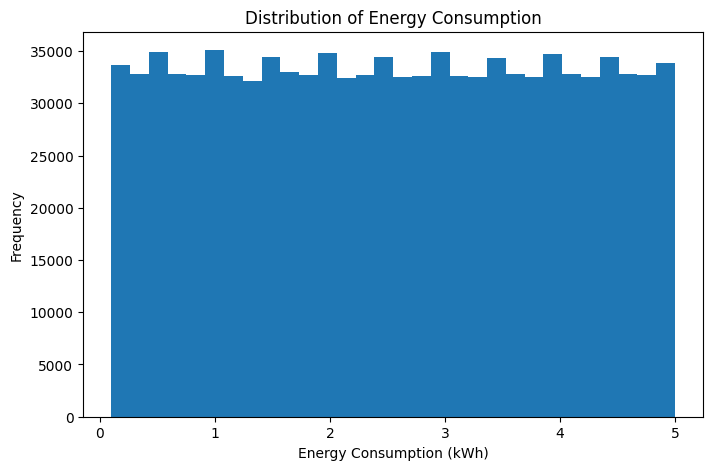

In [22]:
# Distribution of energy consumption
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df2["energy_consumption_kWh"],
    bins=30
)

plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.title("Distribution of Energy Consumption")

plt.show()

In [23]:
# Average energy consumption by appliance category
appliance_mean2 = (
    df2.groupby("appliance")["energy_consumption_kWh"]
    .mean()
    .sort_values(ascending=False)
)

print("Average energy consumption by appliance:")
print(appliance_mean2)

Average energy consumption by appliance:
appliance
Dishwasher         2.555223
HVAC               2.550258
Refrigerator       2.549832
Lighting           2.546810
Washing Machine    2.545603
Electronics        2.545313
Name: energy_consumption_kWh, dtype: float64


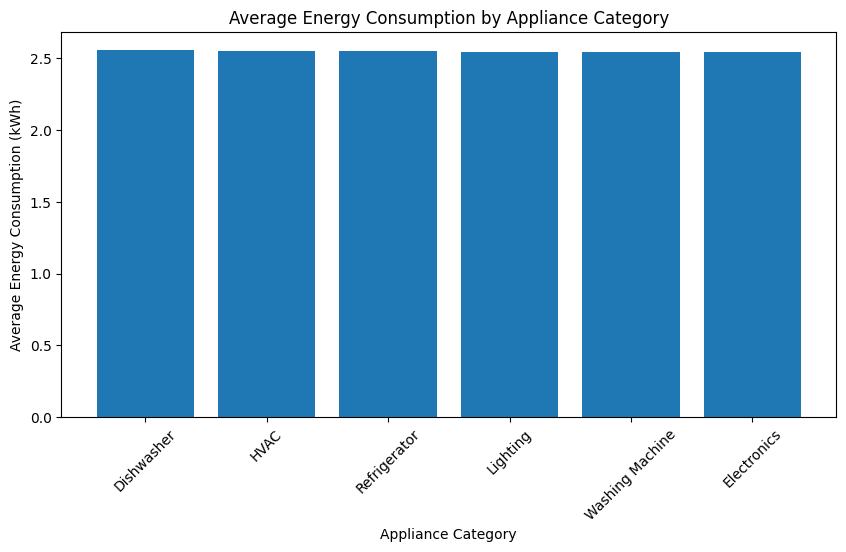

In [24]:
# Plot average energy consumption by appliance
plt.figure(figsize=(10, 5))

plt.bar(
    appliance_mean2.index,
    appliance_mean2.values
)

plt.xlabel("Appliance Category")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Appliance Category")
plt.xticks(rotation=45)

plt.show()

In [25]:
# Average energy consumption by occupancy status
occupancy_mean = (
    df2.groupby("occupancy_status")["energy_consumption_kWh"]
    .mean()
)

print("Average energy consumption by occupancy status:")
print(occupancy_mean)

Average energy consumption by occupancy status:
occupancy_status
Occupied      2.549825
Unoccupied    2.547851
Name: energy_consumption_kWh, dtype: float64


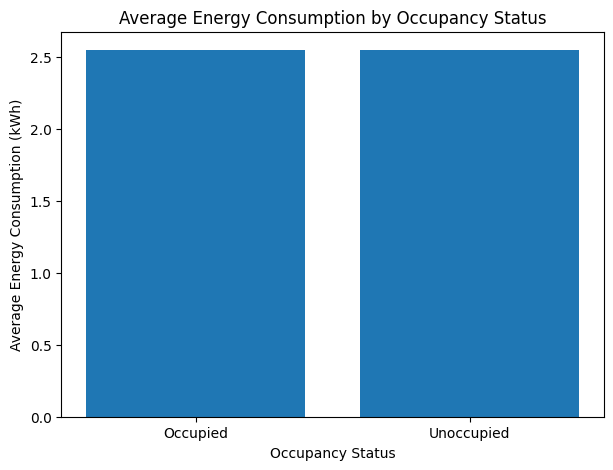

In [26]:
# Plot average energy consumption by occupancy status
plt.figure(figsize=(7, 5))

plt.bar(
    occupancy_mean.index,
    occupancy_mean.values
)
plt.xlabel("Occupancy Status")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Occupancy Status")

plt.show()

In [27]:
# Average energy consumption by season
season_mean2 = (
    df2.groupby("season")["energy_consumption_kWh"]
    .mean()
)

print("Average energy consumption by season:")
print(season_mean2)

Average energy consumption by season:
season
Autumn    2.544037
Spring    2.549561
Summer    2.549385
Winter    2.552380
Name: energy_consumption_kWh, dtype: float64


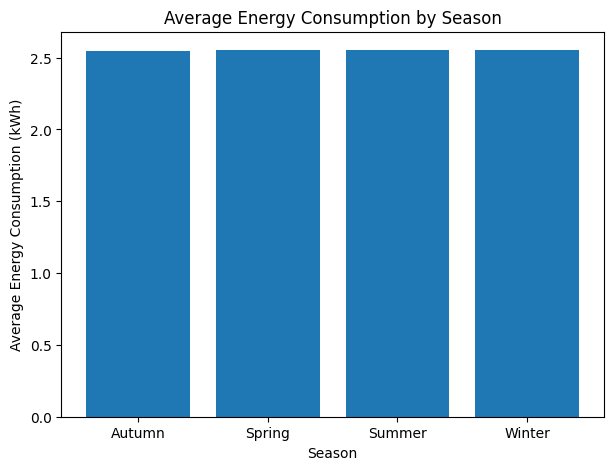

In [28]:
# Plot average energy consumption by season
plt.figure(figsize=(7, 5))

plt.bar(
    season_mean2.index,
    season_mean2.values
)

plt.xlabel("Season")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Season")

plt.show()

# 4. Usage Duration Analysis

In [29]:
# Statistical summary of usage duration
print("Usage duration statistics:")
print(df2["usage_duration_minutes"].describe())

Usage duration statistics:
count    1000000.000000
mean          59.505089
std           34.651890
min            0.000000
25%           30.000000
50%           59.000000
75%           90.000000
max          119.000000
Name: usage_duration_minutes, dtype: float64


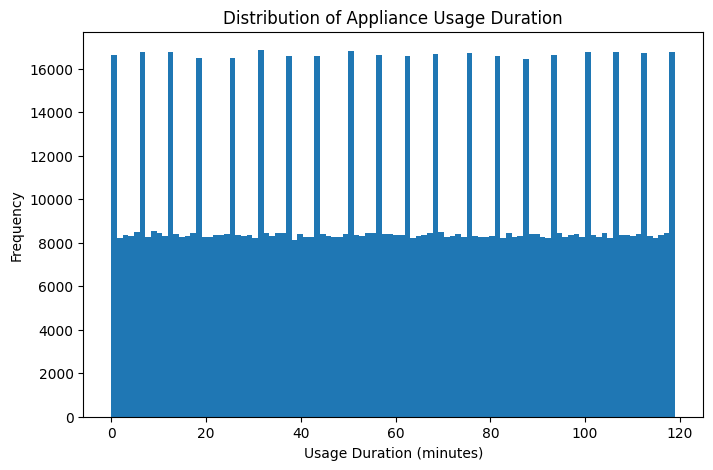

In [30]:
# Distribution of usage duration
plt.figure(figsize=(8, 5))

plt.hist(
    df2["usage_duration_minutes"],
    bins=100
)

plt.xlabel("Usage Duration (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Appliance Usage Duration")

plt.show()

In [31]:
# Average usage duration by appliance
usage_by_appliance = (
    df2.groupby("appliance")["usage_duration_minutes"]
    .mean()
    .sort_values(ascending=False)
)

print("Average usage duration by appliance:")
print(usage_by_appliance)

Average usage duration by appliance:
appliance
Lighting           59.586731
HVAC               59.513580
Dishwasher         59.503094
Electronics        59.492727
Refrigerator       59.487153
Washing Machine    59.446868
Name: usage_duration_minutes, dtype: float64


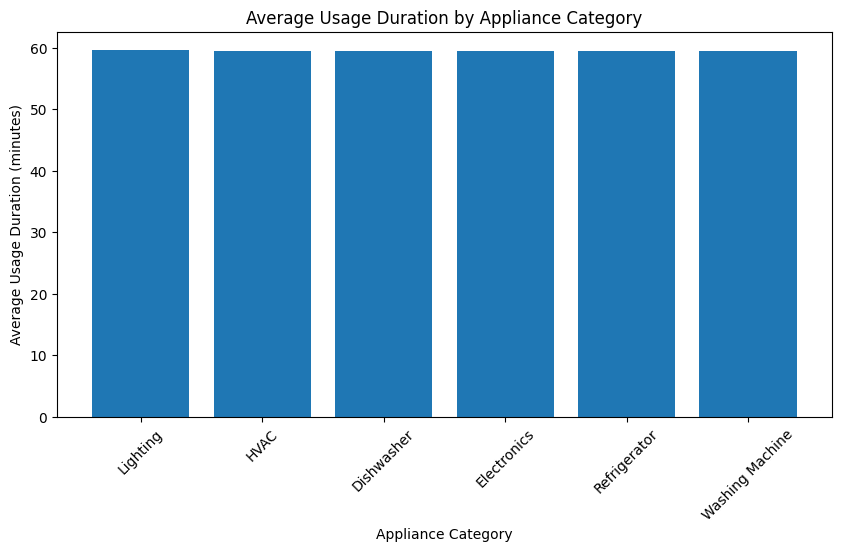

In [32]:
# Plot average usage duration by appliance
plt.figure(figsize=(10, 5))

plt.bar(
    usage_by_appliance.index,
    usage_by_appliance.values
)

plt.xlabel("Appliance Category")
plt.ylabel("Average Usage Duration (minutes)")
plt.title("Average Usage Duration by Appliance Category")
plt.xticks(rotation=45)

plt.show()

In [33]:
# Average energy consumption by usage duration
duration_energy = (
    df2.groupby("usage_duration_minutes")["energy_consumption_kWh"]
    .mean()
)

print("Average energy consumption by usage duration:")
print(duration_energy.head(20))

Average energy consumption by usage duration:
usage_duration_minutes
0     2.561067
1     2.538435
2     2.562406
3     2.553495
4     2.535383
5     2.531826
6     2.541660
7     2.546440
8     2.551727
9     2.556644
10    2.542055
11    2.551663
12    2.532824
13    2.532551
14    2.589291
15    2.546394
16    2.560882
17    2.522915
18    2.554820
19    2.547241
Name: energy_consumption_kWh, dtype: float64


# 5. Temperature & Energy Patterns

In [34]:
# Statistical summary of temperature setting
print("Temperature setting statistics:")
print(df2["temperature_setting_C"].describe())

Temperature setting statistics:
count    1000000.000000
mean          19.999284
std            2.887678
min           15.000000
25%           17.500000
50%           20.000000
75%           22.500000
max           25.000000
Name: temperature_setting_C, dtype: float64


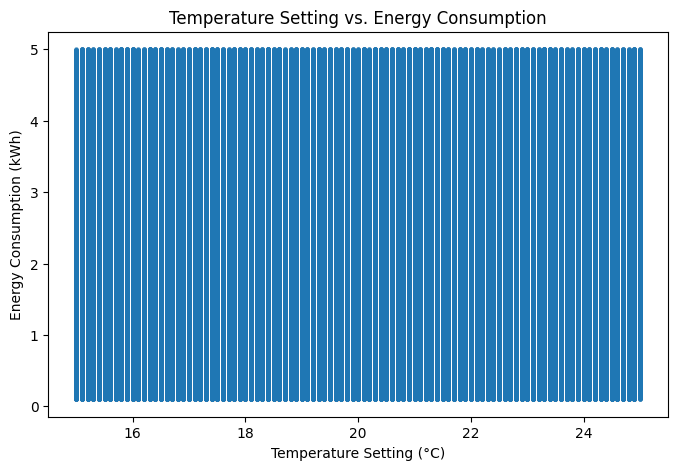

In [35]:
# Temperature vs energy consumption
plt.figure(figsize=(8, 5))

plt.scatter(
    df2["temperature_setting_C"],
    df2["energy_consumption_kWh"],
    s=5,
    alpha=0.3
)

plt.xlabel("Temperature Setting (°C)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Temperature Setting vs. Energy Consumption")

plt.show()

In [36]:
# Correlation between temperature setting and energy consumption
temperature_correlation = (
    df2["temperature_setting_C"]
    .corr(df2["energy_consumption_kWh"])
)
print("Correlation between temperature setting and energy consumption:")
print(temperature_correlation)

Correlation between temperature setting and energy consumption:
-0.0002539738355445682


# 6. Time & Behavioral Patterns

In [37]:
# Convert timestamp temporarily for EDA only
timestamp_data = pd.to_datetime(
    df2["timestamp"]
)

# Check date range
print("Earliest timestamp:")
print(timestamp_data.min())

print("\nLatest timestamp:")
print(timestamp_data.max())

print("\nNumber of unique timestamps:")
print(timestamp_data.nunique())

Earliest timestamp:
2023-01-01 00:00:00

Latest timestamp:
2137-01-29 15:00:00

Number of unique timestamps:
1000000


In [38]:
# Analyze energy consumption by hour
hourly_mean2 = (
    df2.assign(Hour=timestamp_data.dt.hour)
    .groupby("Hour")["energy_consumption_kWh"]
    .mean()
)

print("Average energy consumption by hour:")
print(hourly_mean2)

Average energy consumption by hour:
Hour
0     2.550783
1     2.555333
2     2.544770
3     2.537147
4     2.542013
5     2.560107
6     2.558775
7     2.551164
8     2.538325
9     2.548680
10    2.552573
11    2.536985
12    2.541958
13    2.559188
14    2.546029
15    2.557142
16    2.554206
17    2.540157
18    2.546260
19    2.539725
20    2.556922
21    2.552952
22    2.549552
23    2.551385
Name: energy_consumption_kWh, dtype: float64


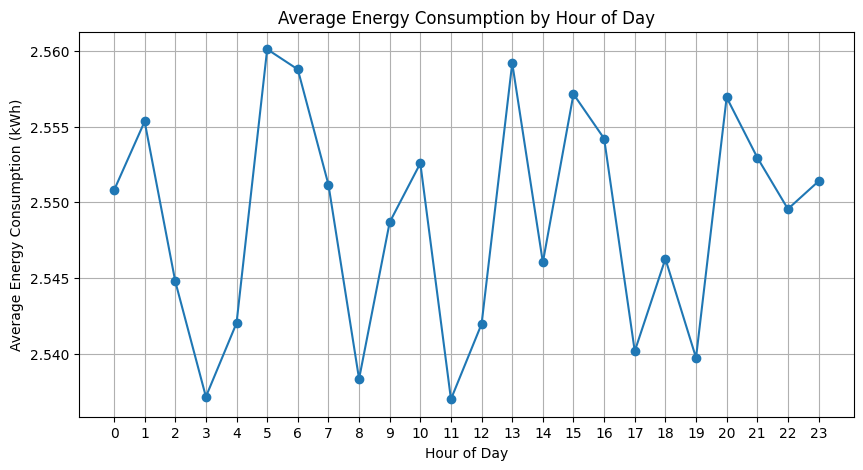

In [39]:
# Plot hourly energy consumption
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_mean2.index,
    hourly_mean2.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Hour of Day")
plt.xticks(range(24))
plt.grid()

plt.show()

In [40]:
# Analyze usage duration by occupancy
occupancy_usage = (
    df2.groupby("occupancy_status")["usage_duration_minutes"]
    .mean()
)

print("Average usage duration by occupancy status:")
print(occupancy_usage)

Average usage duration by occupancy status:
occupancy_status
Occupied      59.564267
Unoccupied    59.445817
Name: usage_duration_minutes, dtype: float64


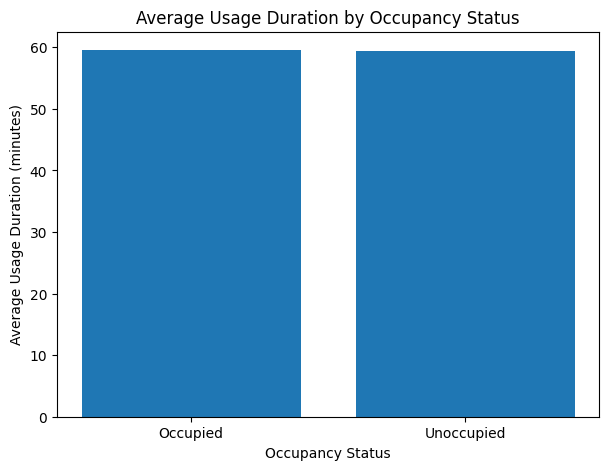

In [41]:
# Plot usage duration by occupancy
plt.figure(figsize=(7, 5))

plt.bar(
    occupancy_usage.index,
    occupancy_usage.values
)

plt.xlabel("Occupancy Status")
plt.ylabel("Average Usage Duration (minutes)")
plt.title("Average Usage Duration by Occupancy Status")

plt.show()

# 7. Day of Week & Holiday Analysis

In [42]:
# Average energy consumption by day of week
day_energy = (
    df2.groupby("day_of_week")["energy_consumption_kWh"]
    .mean()
)

print("Average energy consumption by day of week:")
print(day_energy)

Average energy consumption by day of week:
day_of_week
Friday       2.558189
Monday       2.546828
Saturday     2.544319
Sunday       2.545478
Thursday     2.547493
Tuesday      2.547565
Wednesday    2.552000
Name: energy_consumption_kWh, dtype: float64


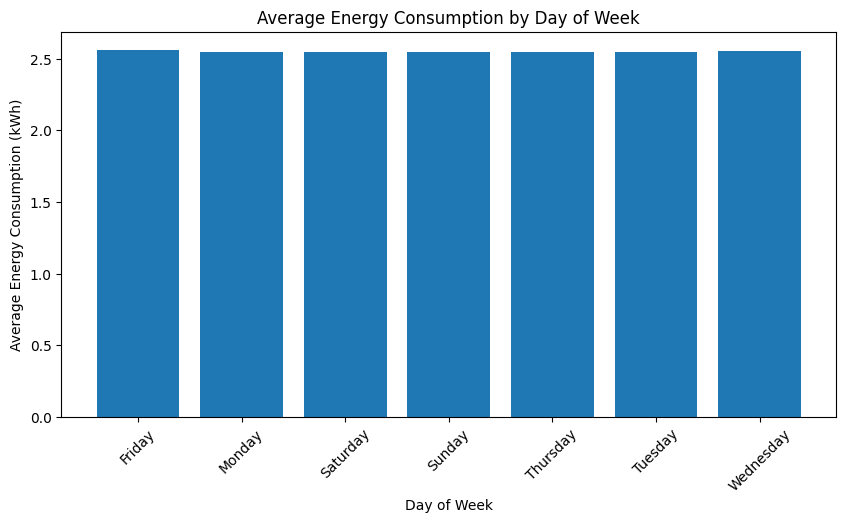

In [43]:
# Plot energy consumption by day of week
plt.figure(figsize=(10, 5))

plt.bar(
    day_energy.index,
    day_energy.values
)

plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Day of Week")
plt.xticks(rotation=45)

plt.show()

In [44]:
# Average energy consumption by holiday status
holiday_energy = (
    df2.groupby("holiday")["energy_consumption_kWh"]
    .mean()
)

print("Average energy consumption by holiday status:")
print(holiday_energy)

Average energy consumption by holiday status:
holiday
0    2.548388
1    2.552916
Name: energy_consumption_kWh, dtype: float64


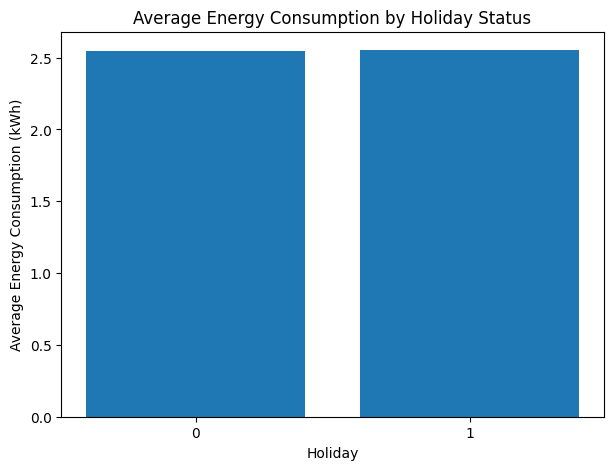

In [45]:
# Plot energy consumption by holiday status
plt.figure(figsize=(7, 5))

plt.bar(
    holiday_energy.index.astype(str),
    holiday_energy.values
)

plt.xlabel("Holiday")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption by Holiday Status")

plt.show()

# 8. Correlation Analysis

In [46]:
# Correlations between numerical variables
correlation_matrix2 = df2[
    [
        "energy_consumption_kWh",
        "temperature_setting_C",
        "usage_duration_minutes"
    ]
].corr()

print("Correlation Matrix:")
print(correlation_matrix2)

Correlation Matrix:
                        energy_consumption_kWh  temperature_setting_C  \
energy_consumption_kWh                1.000000              -0.000254   
temperature_setting_C                -0.000254               1.000000   
usage_duration_minutes                0.000486              -0.001716   

                        usage_duration_minutes  
energy_consumption_kWh                0.000486  
temperature_setting_C                -0.001716  
usage_duration_minutes                1.000000  


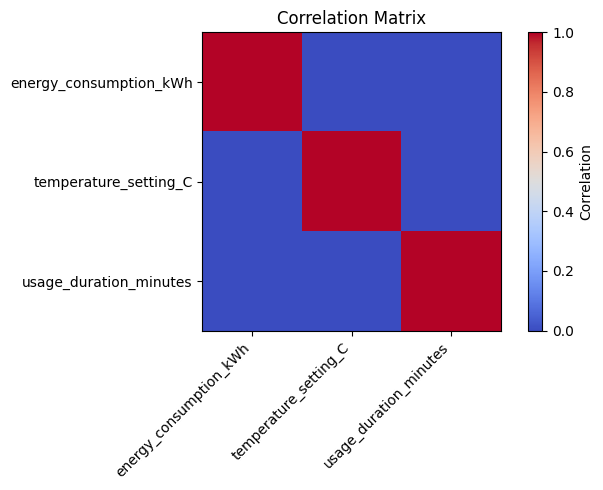

In [ ]:
# Correlation heatmap

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix2,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(correlation_matrix2.columns)),
    correlation_matrix2.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix2.columns)),
    correlation_matrix2.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix")

for i in range(len(correlation_matrix2.columns)):
    for j in range(len(correlation_matrix2.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix2.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# 9. Outlier Investigation

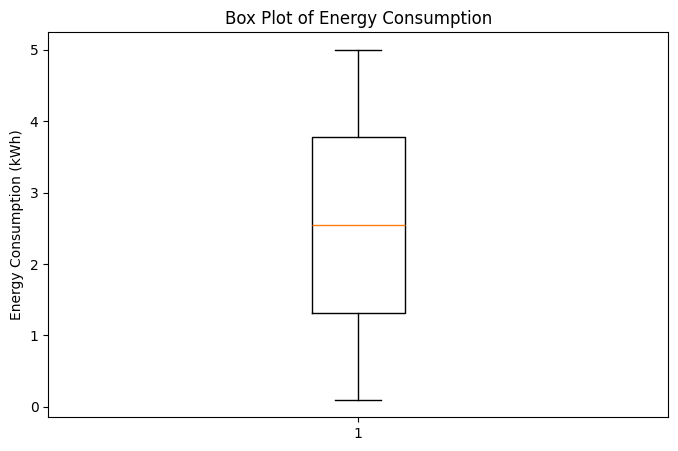

In [48]:
# Box plot for energy consumption
plt.figure(figsize=(8, 5))

plt.boxplot(
    df2["energy_consumption_kWh"],
    flierprops=dict(
        marker=".",
        markersize=2
    )
)

plt.ylabel("Energy Consumption (kWh)")
plt.title("Box Plot of Energy Consumption")

plt.show()

In [49]:
# IQR method for potential energy outliers
Q1_2 = df2["energy_consumption_kWh"].quantile(0.25)
Q3_2 = df2["energy_consumption_kWh"].quantile(0.75)

IQR_2 = Q3_2 - Q1_2

lower_bound_2 = Q1_2 - 1.5 * IQR_2
upper_bound_2 = Q3_2 + 1.5 * IQR_2

outliers2 = df2[
    (df2["energy_consumption_kWh"] < lower_bound_2) |
    (df2["energy_consumption_kWh"] > upper_bound_2)
]

print("Q1:", Q1_2)
print("Q3:", Q3_2)
print("IQR:", IQR_2)

print("\nLower bound:", lower_bound_2)
print("Upper bound:", upper_bound_2)

print("\nNumber of potential outliers:", len(outliers2))

print(
    "Percentage of potential outliers:",
    len(outliers2) / len(df2) * 100
)

Q1: 1.32
Q3: 3.78
IQR: 2.46

Lower bound: -2.37
Upper bound: 7.47

Number of potential outliers: 0
Percentage of potential outliers: 0.0


# 10. Appliance-Level Energy Distribution

In [50]:
# Compare average and maximum energy consumption
appliance_stats2 = (
    df2.groupby("appliance")["energy_consumption_kWh"]
    .agg(["mean", "max"])
    .sort_values("mean", ascending=False)
)

print("Energy consumption statistics by appliance:")
print(appliance_stats2)

Energy consumption statistics by appliance:
                     mean  max
appliance                     
Dishwasher       2.555223  5.0
HVAC             2.550258  5.0
Refrigerator     2.549832  5.0
Lighting         2.546810  5.0
Washing Machine  2.545603  5.0
Electronics      2.545313  5.0


<Figure size 1200x600 with 0 Axes>

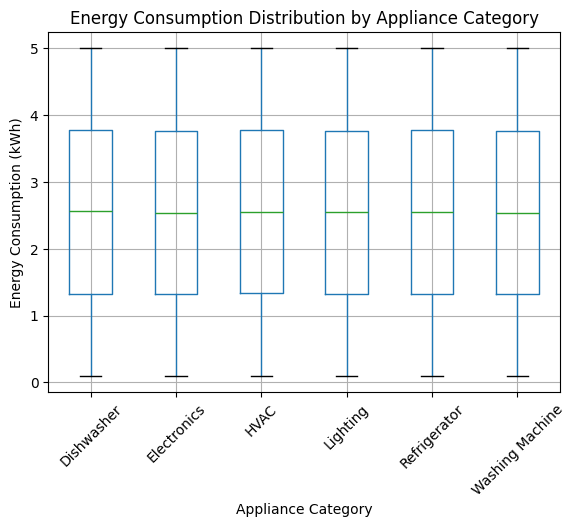

In [51]:
# Box plot by appliance
plt.figure(figsize=(12, 6))

df2.boxplot(
    column="energy_consumption_kWh",
    by="appliance",
    rot=45
)

plt.xlabel("Appliance Category")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Energy Consumption Distribution by Appliance Category")
plt.suptitle("")

plt.show()

# Dataset 3 — Household Appliances

In [52]:
dataset3_path = "/content/drive/MyDrive/Smart_Home_Energy_Project/dataset3_selected_appliances.csv"

# Load Dataset 3
df3 = pd.read_csv(dataset3_path)
df3_original = df3.copy()

# Display the first 5 rows
print("First 5 rows:")
print(df3.head())

First 5 rows:
    id                   first_ts                    last_ts  \
0  343  2021-04-04 21:46:29+00:00  2021-05-03 23:59:59+00:00   
1  295  2021-01-16 07:39:05+00:00  2021-02-15 07:39:05+00:00   
2   32  2021-01-18 11:13:03+00:00  2021-02-17 11:13:02+00:00   
3   53  2021-01-18 00:51:25+00:00  2021-02-17 00:51:25+00:00   
4  226  2021-02-18 05:28:53+00:00  2021-03-20 05:28:52+00:00   

   available_duration        plug_name standardized_appliance_name  \
0               29.09  washing_machine             washing_machine   
1               30.00  internet_router             internet_router   
2               30.00  washing_machine             washing_machine   
3               30.00       dishwasher                  dishwasher   
4               30.00           boiler                      boiler   

  appliance_category                                            comment  \
0            washing                                                NaN   
1         multimedia          

# 2. Dataset Overview & Data Quality

In [53]:
print("Dataset shape:")
print(df3.shape)

print("\nDataset information:")
df3.info()

print("\nMissing values:")
print(df3.isnull().sum())

print("\nExact duplicate rows:")
print(df3.duplicated().sum())

Dataset shape:
(33, 10)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           33 non-null     int64  
 1   first_ts                     33 non-null     object 
 2   last_ts                      33 non-null     object 
 3   available_duration           33 non-null     float64
 4   plug_name                    33 non-null     object 
 5   standardized_appliance_name  33 non-null     object 
 6   appliance_category           33 non-null     object 
 7   comment                      20 non-null     object 
 8   files_names                  33 non-null     object 
 9   power_max                    33 non-null     float64
dtypes: float64(2), int64(1), object(7)
memory usage: 2.7+ KB

Missing values:
id                              0
first_ts                        0
last_ts 

# 3. Understanding the Variables

In [54]:
print("Column names:")
print(df3.columns.tolist())

print("\nData types:")
print(df3.dtypes)

print("\nStandardized appliance names:")
print(df3["standardized_appliance_name"].value_counts())

print("\nAppliance categories:")
print(df3["appliance_category"].value_counts())

Column names:
['id', 'first_ts', 'last_ts', 'available_duration', 'plug_name', 'standardized_appliance_name', 'appliance_category', 'comment', 'files_names', 'power_max']

Data types:
id                               int64
first_ts                        object
last_ts                         object
available_duration             float64
plug_name                       object
standardized_appliance_name     object
appliance_category              object
comment                         object
files_names                     object
power_max                      float64
dtype: object

Standardized appliance names:
standardized_appliance_name
washing_machine    6
fridge             4
boiler             3
coffee             3
internet_router    2
micro_wave_oven    2
laptop             2
screen             2
dishwasher         1
phone_charger      1
sound_system       1
tv                 1
fan                1
air_conditioner    1
computer           1
dryer              1
freezer          

# 4. Appliance Distribution

In [55]:
# Count the number of devices for each standardized appliance
appliance_counts = (
    df3["standardized_appliance_name"]
    .value_counts()
)

print("Number of devices by appliance:")
print(appliance_counts)

Number of devices by appliance:
standardized_appliance_name
washing_machine    6
fridge             4
boiler             3
coffee             3
internet_router    2
micro_wave_oven    2
laptop             2
screen             2
dishwasher         1
phone_charger      1
sound_system       1
tv                 1
fan                1
air_conditioner    1
computer           1
dryer              1
freezer            1
Name: count, dtype: int64


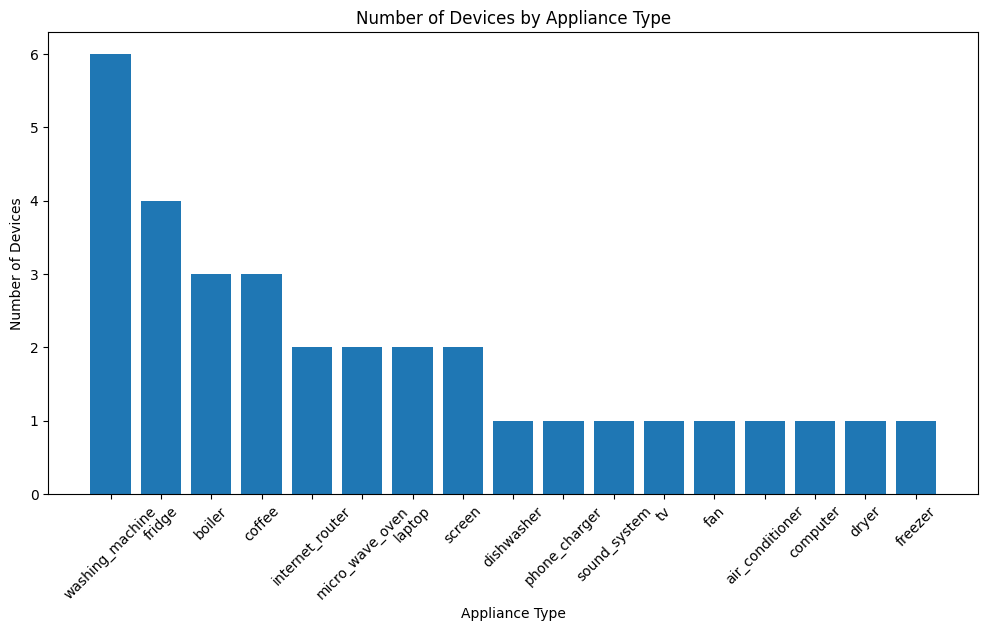

In [56]:
# Plot number of devices by appliance
plt.figure(figsize=(12, 6))

plt.bar(
    appliance_counts.index,
    appliance_counts.values
)

plt.xlabel("Appliance Type")
plt.ylabel("Number of Devices")
plt.title("Number of Devices by Appliance Type")
plt.xticks(rotation=45)

plt.show()

# 5. Appliance Category Distribution

In [57]:
category_counts = (
    df3["appliance_category"]
    .value_counts()
)

print("Number of devices by appliance category:")
print(category_counts)

Number of devices by appliance category:
appliance_category
kitchen       13
multimedia    10
washing        8
cooling        2
Name: count, dtype: int64


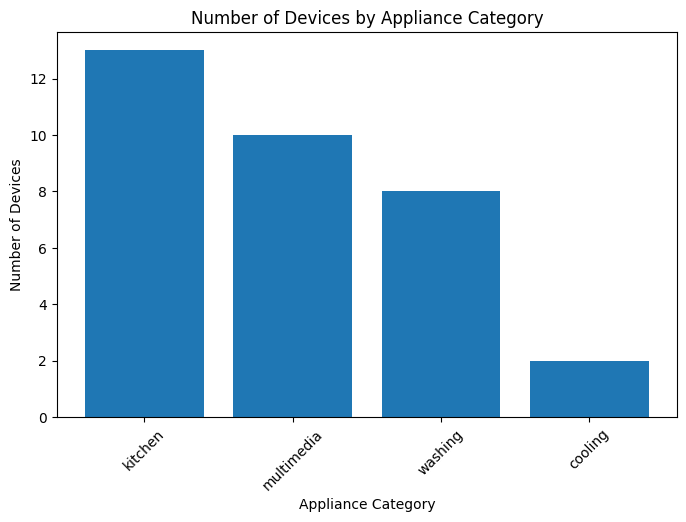

In [58]:
# Plot appliance categories
plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Appliance Category")
plt.ylabel("Number of Devices")
plt.title("Number of Devices by Appliance Category")
plt.xticks(rotation=45)

plt.show()

# 6. Available Duration Analysis

In [59]:
print("Available duration statistics:")
print(df3["available_duration"].describe())

Available duration statistics:
count    33.000000
mean     29.412424
std       3.002208
min      12.730000
25%      30.000000
50%      30.000000
75%      30.000000
max      30.000000
Name: available_duration, dtype: float64


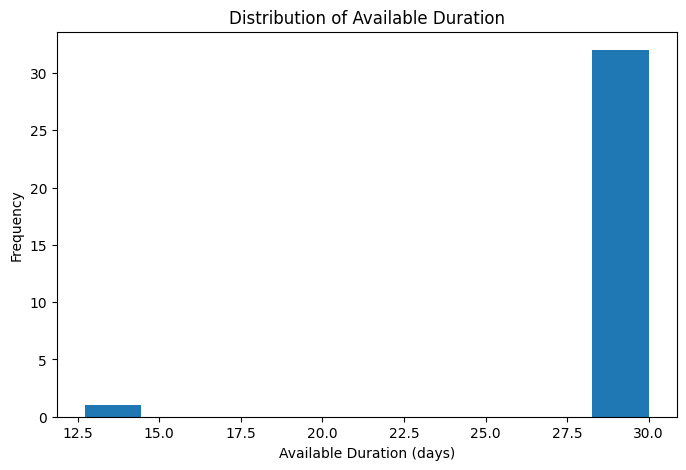

In [60]:
# Plot available duration
plt.figure(figsize=(8, 5))

plt.hist(
    df3["available_duration"],
    bins=10
)

plt.xlabel("Available Duration (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Available Duration")

plt.show()

# 7. Power Consumption Analysis

In [61]:
print("Power maximum statistics:")
print(df3["power_max"].describe())

Power maximum statistics:
count      33.000000
mean     1246.075758
std      1084.158473
min        16.000000
25%        61.000000
50%      1399.000000
75%      2171.000000
max      3267.000000
Name: power_max, dtype: float64


In [62]:
# Check minimum and maximum power values
print("\nMinimum recorded power:")
print(df3["power_max"].min())

print("\nMaximum recorded power:")
print(df3["power_max"].max())


Minimum recorded power:
16.0

Maximum recorded power:
3267.0


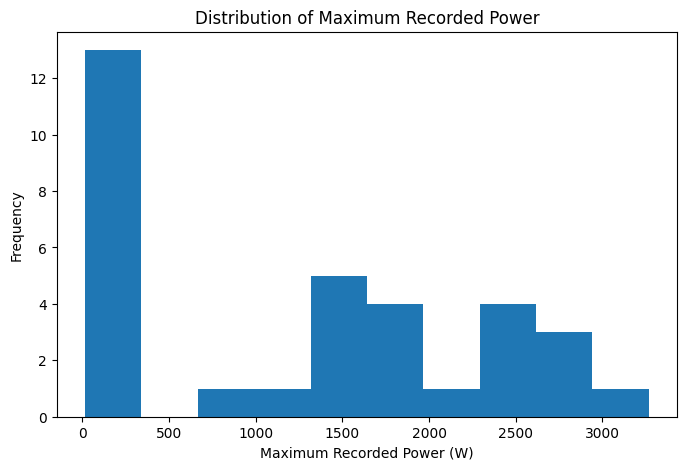

In [63]:
# Plot power maximum distribution
plt.figure(figsize=(8, 5))

plt.hist(
    df3["power_max"],
    bins=10
)

plt.xlabel("Maximum Recorded Power (W)")
plt.ylabel("Frequency")
plt.title("Distribution of Maximum Recorded Power")

plt.show()

# 8. Power by Appliance Type

In [64]:
# Compare maximum recorded power across appliance types
appliance_power = (
    df3.groupby("standardized_appliance_name")["power_max"]
    .agg(["min", "mean", "max"])
    .sort_values("mean", ascending=False)
)

print("Power statistics by appliance:")
print(appliance_power)

Power statistics by appliance:
                                min         mean     max
standardized_appliance_name                             
dryer                        3267.0  3267.000000  3267.0
boiler                       2545.0  2605.500000  2664.0
washing_machine              1955.0  2430.666667  2688.0
dishwasher                   1806.0  1806.000000  1806.0
micro_wave_oven              1712.0  1757.000000  1802.0
freezer                      1623.0  1623.000000  1623.0
coffee                       1373.0  1417.666667  1481.0
fridge                        280.0   864.750000  1436.0
computer                      280.0   280.000000   280.0
phone_charger                  86.0    86.000000    86.0
fan                            83.0    83.000000    83.0
laptop                         55.0    58.000000    61.0
tv                             54.0    54.000000    54.0
air_conditioner                45.0    45.000000    45.0
screen                         30.0    31.500000    33.0


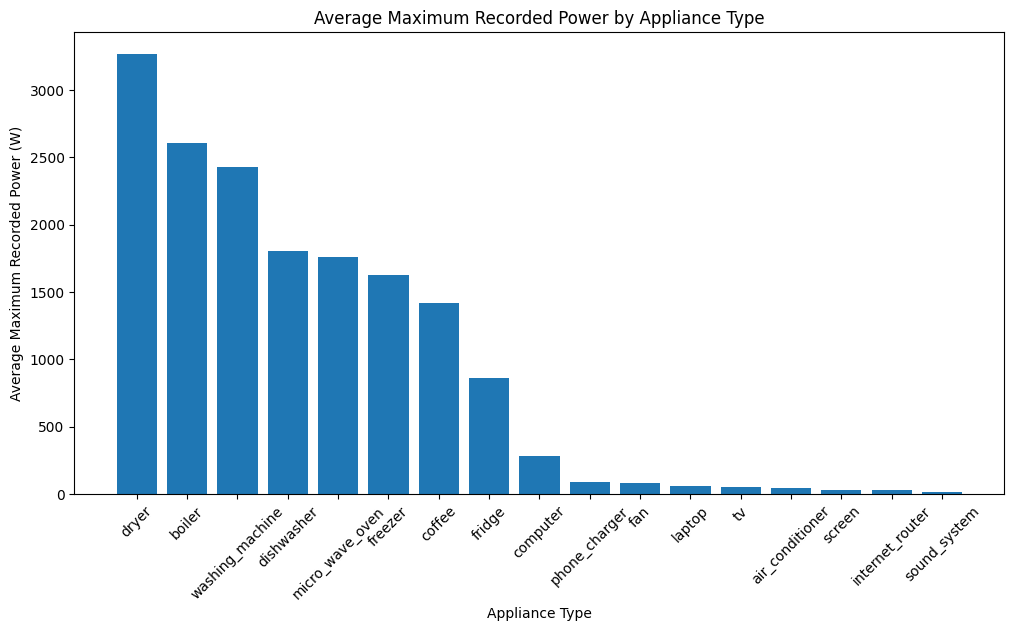

In [65]:
# Plot average maximum recorded power by appliance
appliance_power_mean = (
    df3.groupby("standardized_appliance_name")["power_max"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    appliance_power_mean.index,
    appliance_power_mean.values
)

plt.xlabel("Appliance Type")
plt.ylabel("Average Maximum Recorded Power (W)")
plt.title("Average Maximum Recorded Power by Appliance Type")
plt.xticks(rotation=45)

plt.show()

# 9. Appliance-Level Power Distribution

<Figure size 1200x600 with 0 Axes>

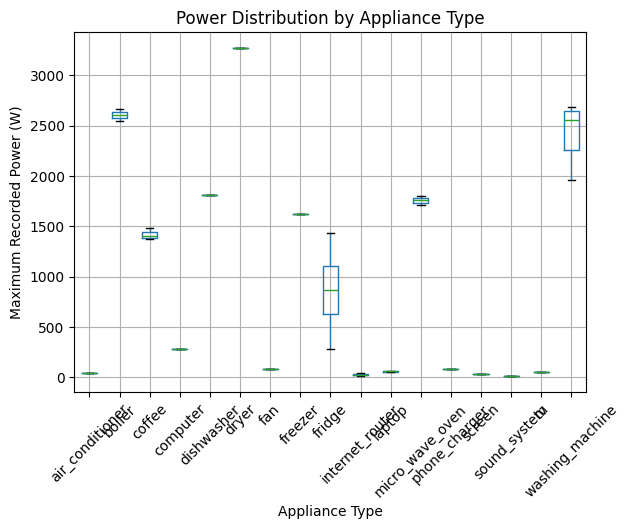

In [66]:
plt.figure(figsize=(12, 6))

df3.boxplot(
    column="power_max",
    by="standardized_appliance_name",
    rot=45
)

plt.xlabel("Appliance Type")
plt.ylabel("Maximum Recorded Power (W)")
plt.title("Power Distribution by Appliance Type")
plt.suptitle("")

plt.show()

# 10. Appliance Availability Analysis

In [67]:
# Average available duration by appliance
availability_by_appliance = (
    df3.groupby("standardized_appliance_name")["available_duration"]
    .mean()
    .sort_values(ascending=False)
)

print("Average available duration by appliance:")
print(availability_by_appliance)

Average available duration by appliance:
standardized_appliance_name
air_conditioner    30.000
boiler             30.000
coffee             30.000
computer           30.000
dishwasher         30.000
dryer              30.000
fan                30.000
freezer            30.000
fridge             30.000
internet_router    30.000
micro_wave_oven    30.000
phone_charger      30.000
sound_system       30.000
tv                 30.000
washing_machine    29.740
laptop             29.720
screen             21.365
Name: available_duration, dtype: float64


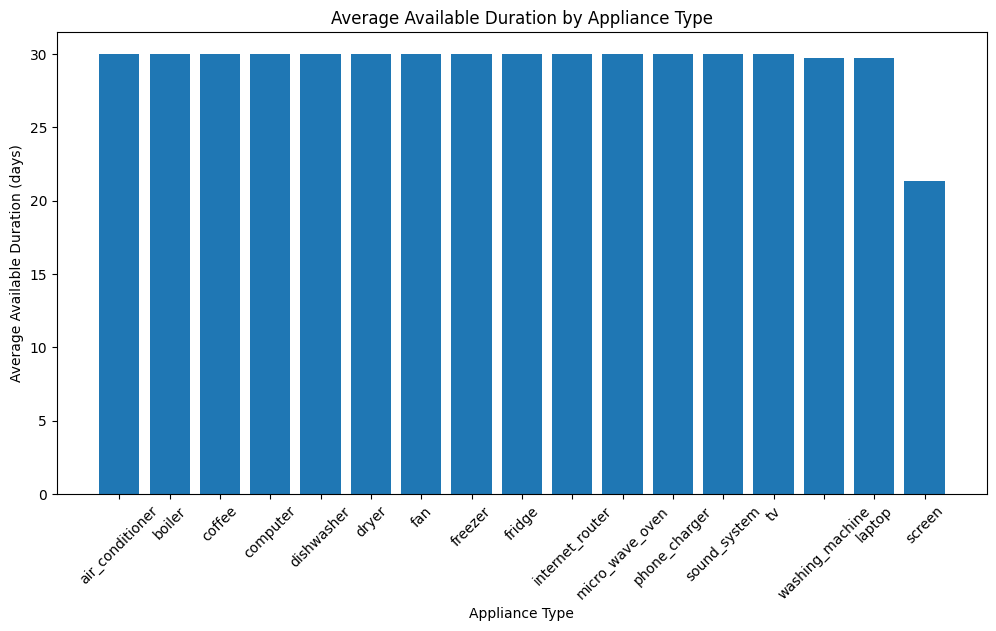

In [68]:
# Plot average available duration by appliance
plt.figure(figsize=(12, 6))

plt.bar(
    availability_by_appliance.index,
    availability_by_appliance.values
)

plt.xlabel("Appliance Type")
plt.ylabel("Average Available Duration (days)")
plt.title("Average Available Duration by Appliance Type")
plt.xticks(rotation=45)

plt.show()

# 11. Outlier Investigation — Power

In [69]:
Q1_power = df3["power_max"].quantile(0.25)
Q3_power = df3["power_max"].quantile(0.75)

IQR_power = Q3_power - Q1_power

lower_power_bound = Q1_power - 1.5 * IQR_power
upper_power_bound = Q3_power + 1.5 * IQR_power

power_outliers = df3[
    (df3["power_max"] < lower_power_bound) |
    (df3["power_max"] > upper_power_bound)
]

print("Q1:", Q1_power)
print("Q3:", Q3_power)
print("IQR:", IQR_power)

print("\nLower bound:", lower_power_bound)
print("Upper bound:", upper_power_bound)

print("\nNumber of potential power outliers:")
print(len(power_outliers))

print("\nPercentage of potential power outliers:")
print(len(power_outliers) / len(df3) * 100)

Q1: 61.0
Q3: 2171.0
IQR: 2110.0

Lower bound: -3104.0
Upper bound: 5336.0

Number of potential power outliers:
0

Percentage of potential power outliers:
0.0


# 12. Check Appliance Metadata

In [70]:
print("Unique original plug names:")
print(df3["plug_name"].nunique())

print("\nUnique standardized appliance names:")
print(df3["standardized_appliance_name"].nunique())

print("\nUnique appliance categories:")
print(df3["appliance_category"].nunique())

Unique original plug names:
17

Unique standardized appliance names:
17

Unique appliance categories:
4


In [71]:
# Check whether each standardized appliance has multiple devices
appliance_device_counts = (
    df3.groupby("standardized_appliance_name")["id"]
    .count()
    .sort_values(ascending=False)
)

print("\nNumber of devices per standardized appliance:")
print(appliance_device_counts)


Number of devices per standardized appliance:
standardized_appliance_name
washing_machine    6
fridge             4
coffee             3
boiler             3
laptop             2
internet_router    2
micro_wave_oven    2
screen             2
air_conditioner    1
freezer            1
fan                1
dryer              1
dishwasher         1
computer           1
phone_charger      1
sound_system       1
tv                 1
Name: id, dtype: int64


# **Additional EDA — Deeper Relationships**
These sections extend the original EDA without modifying any previous cells.

## 13. Dataset 1 — Home-Level Energy Analysis
Check how average energy consumption differs between homes and whether some homes have much more data than others.

Number of homes: 500

Top 10 homes by average energy consumption:
         count      mean     sum
Home ID                         
193        187  1.754920  328.17
324        213  1.739437  370.50
77         193  1.688135  325.81
170        204  1.671373  340.96
302        180  1.671056  300.79
423        225  1.670222  375.80
321        198  1.667323  330.13
441        209  1.666220  348.24
84         196  1.661888  325.73
143        226  1.660619  375.30


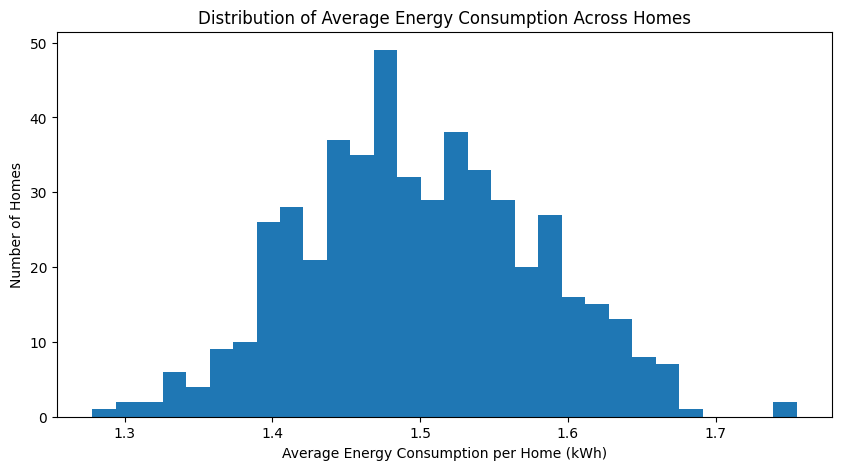

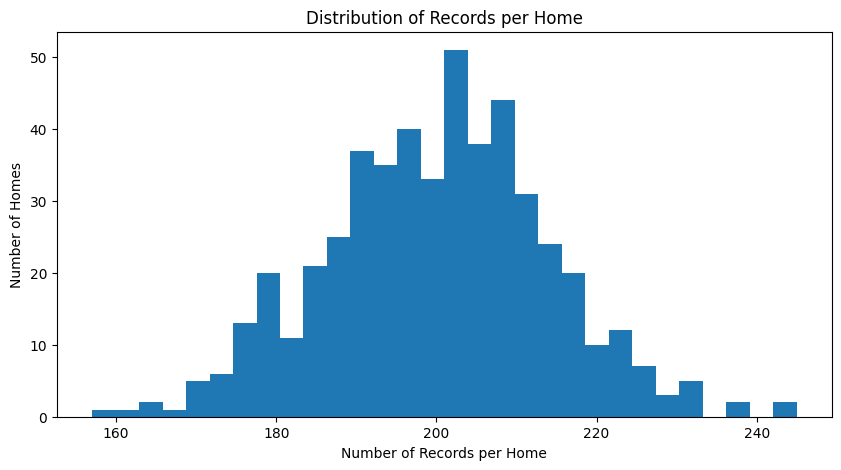

In [72]:
home_energy = (
    df1.groupby("Home ID")["Energy Consumption (kWh)"]
    .agg(["count", "mean", "sum"])
    .sort_values("mean", ascending=False)
)

print("Number of homes:", df1["Home ID"].nunique())
print("\nTop 10 homes by average energy consumption:")
print(home_energy.head(10))

plt.figure(figsize=(10, 5))
plt.hist(home_energy["mean"], bins=30)
plt.xlabel("Average Energy Consumption per Home (kWh)")
plt.ylabel("Number of Homes")
plt.title("Distribution of Average Energy Consumption Across Homes")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(home_energy["count"], bins=30)
plt.xlabel("Number of Records per Home")
plt.ylabel("Number of Homes")
plt.title("Distribution of Records per Home")
plt.show()

## 14. Dataset 1 — Temperature × Appliance
The overall temperature-energy relationship may hide appliance-specific patterns.

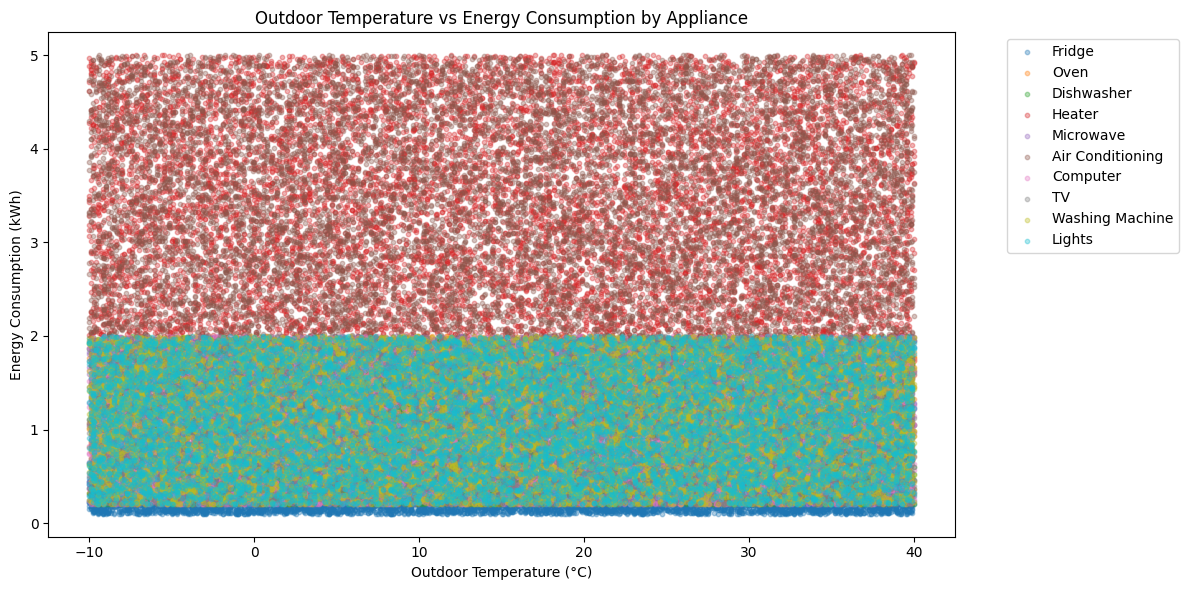

In [73]:
plt.figure(figsize=(12, 6))
for appliance in df1["Appliance Type"].dropna().unique():
    subset = df1[df1["Appliance Type"] == appliance]
    plt.scatter(
        subset["Outdoor Temperature (°C)"],
        subset["Energy Consumption (kWh)"],
        s=10,
        alpha=0.35,
        label=appliance
    )
plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Outdoor Temperature vs Energy Consumption by Appliance")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 15. Dataset 1 — Hour × Appliance
Compare the hourly energy pattern of different appliance types.

Average energy consumption by hour and appliance:
Appliance Type  Air Conditioning  Computer  Dishwasher    Fridge    Heater  \
Hour                                                                         
0                       3.532068  1.050766    1.118626  0.299163  3.457529   
1                       3.549877  1.089375    1.116533  0.307139  3.492289   
2                       3.463364  1.086092    1.121525  0.297780  3.470615   
3                       3.461367  1.060933    1.115267  0.306280  3.470336   
4                       3.519118  1.138558    1.098386  0.305835  3.467482   
5                       3.487034  1.088431    1.086410  0.295272  3.457000   
6                       3.463066  1.119835    1.128799  0.284196  3.464057   
7                       3.496210  1.079104    1.093480  0.293414  3.496310   
8                       3.473744  1.079075    1.114434  0.300251  3.445118   
9                       3.529773  1.040678    1.082375  0.300789  3.567772   
10            

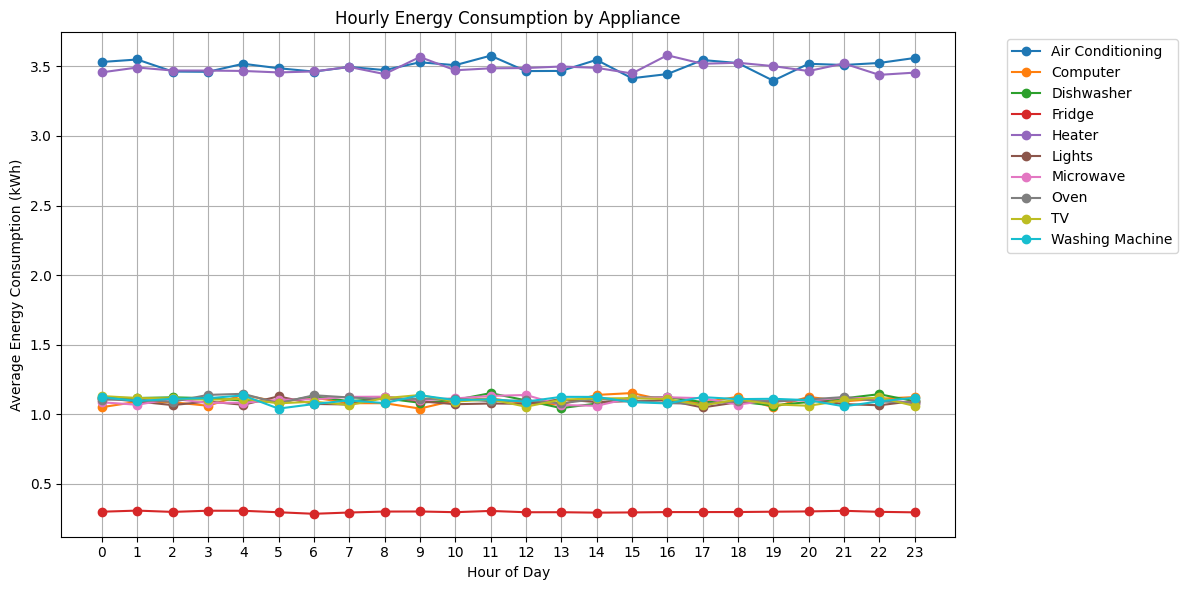

In [74]:
time_data_extra = pd.to_datetime(df1["Time"], format="%H:%M")
hour_appliance = (
    df1.assign(Hour=time_data_extra.dt.hour)
    .groupby(["Hour", "Appliance Type"])["Energy Consumption (kWh)"]
    .mean()
    .unstack()
)

print("Average energy consumption by hour and appliance:")
print(hour_appliance)

plt.figure(figsize=(12, 6))
for appliance in hour_appliance.columns:
    plt.plot(hour_appliance.index, hour_appliance[appliance], marker="o", label=appliance)
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Hourly Energy Consumption by Appliance")
plt.xticks(range(24))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.tight_layout()
plt.show()

## 16. Dataset 2 — Timestamp Features
Extract month, weekday, and weekend information to examine broader temporal patterns.

In [75]:
df2_time_extra = pd.to_datetime(df2["timestamp"])
df2_time_features = df2.assign(
    Month=df2_time_extra.dt.month,
    Weekday=df2_time_extra.dt.day_name(),
    Weekend=df2_time_extra.dt.dayofweek >= 5
)

monthly_energy2 = df2_time_features.groupby("Month")["energy_consumption_kWh"].mean()
weekday_energy2 = df2_time_features.groupby("Weekday")["energy_consumption_kWh"].mean()
weekend_energy2 = df2_time_features.groupby("Weekend")["energy_consumption_kWh"].mean()

print("Average energy by month:")
print(monthly_energy2)
print("\nAverage energy by weekday:")
print(weekday_energy2)
print("\nAverage energy by weekend status:")
print(weekend_energy2)

Average energy by month:
Month
1     2.545587
2     2.549466
3     2.553141
4     2.548438
5     2.546174
6     2.559354
7     2.553859
8     2.547420
9     2.548928
10    2.546688
11    2.542127
12    2.545077
Name: energy_consumption_kWh, dtype: float64

Average energy by weekday:
Weekday
Friday       2.558189
Monday       2.546828
Saturday     2.544319
Sunday       2.545478
Thursday     2.547493
Tuesday      2.547565
Wednesday    2.552000
Name: energy_consumption_kWh, dtype: float64

Average energy by weekend status:
Weekend
False    2.550415
True     2.544898
Name: energy_consumption_kWh, dtype: float64


## 17. Dataset 2 — Appliance × Occupancy
Examine whether appliance energy consumption changes with occupancy status.

Average energy by appliance and occupancy:
occupancy_status  Occupied  Unoccupied
appliance                             
Dishwasher        2.556780    2.553675
Electronics       2.549542    2.541071
HVAC              2.545591    2.554939
Lighting          2.554677    2.538880
Refrigerator      2.549128    2.550534
Washing Machine   2.543218    2.548001


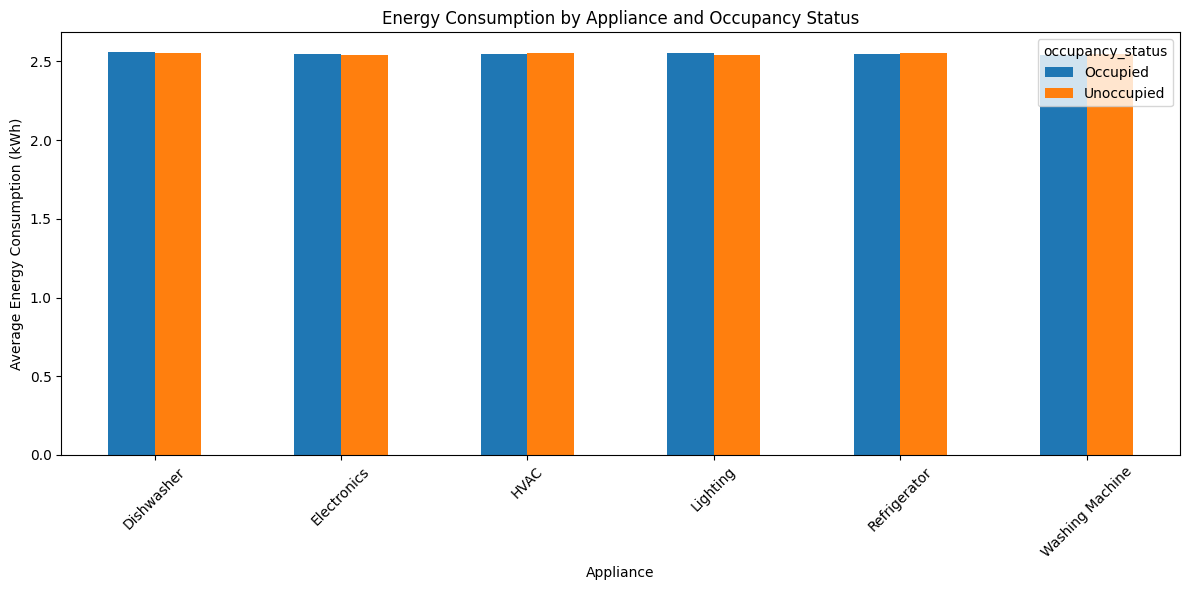

In [76]:
appliance_occupancy_energy = (
    df2.groupby(["appliance", "occupancy_status"])["energy_consumption_kWh"]
    .mean()
    .unstack()
)

print("Average energy by appliance and occupancy:")
print(appliance_occupancy_energy)

appliance_occupancy_energy.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Appliance")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Energy Consumption by Appliance and Occupancy Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Dataset 2 — Usage Duration vs Energy
A scatter plot makes the relationship between duration and energy easier to inspect than grouped values alone.

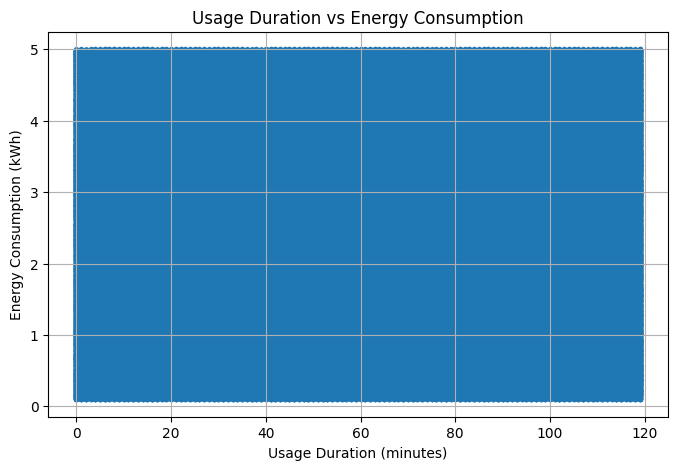

Correlation between usage duration and energy: 0.0004860906448792591


In [77]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df2["usage_duration_minutes"],
    df2["energy_consumption_kWh"],
    s=8,
    alpha=0.25
)
plt.xlabel("Usage Duration (minutes)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Usage Duration vs Energy Consumption")
plt.grid()
plt.show()

print("Correlation between usage duration and energy:",
      df2["usage_duration_minutes"].corr(df2["energy_consumption_kWh"]))

## 19. Dataset 3 — Estimated Energy Potential
If `power_max` is measured in watts and `available_duration` represents days, this is a simple theoretical upper-bound indicator, not measured consumption.

Theoretical energy potential by appliance (Wh):
standardized_appliance_name
dryer              2352240.00
boiler             1875960.00
washing_machine    1734742.08
dishwasher         1300320.00
micro_wave_oven    1265040.00
freezer            1168560.00
coffee             1020720.00
fridge              622620.00
computer            201600.00
phone_charger        61920.00
fan                  59760.00
laptop               41390.40
tv                   38880.00
air_conditioner      32400.00
internet_router      19440.00
screen               15841.08
sound_system         12240.00
Name: theoretical_energy_Wh, dtype: float64


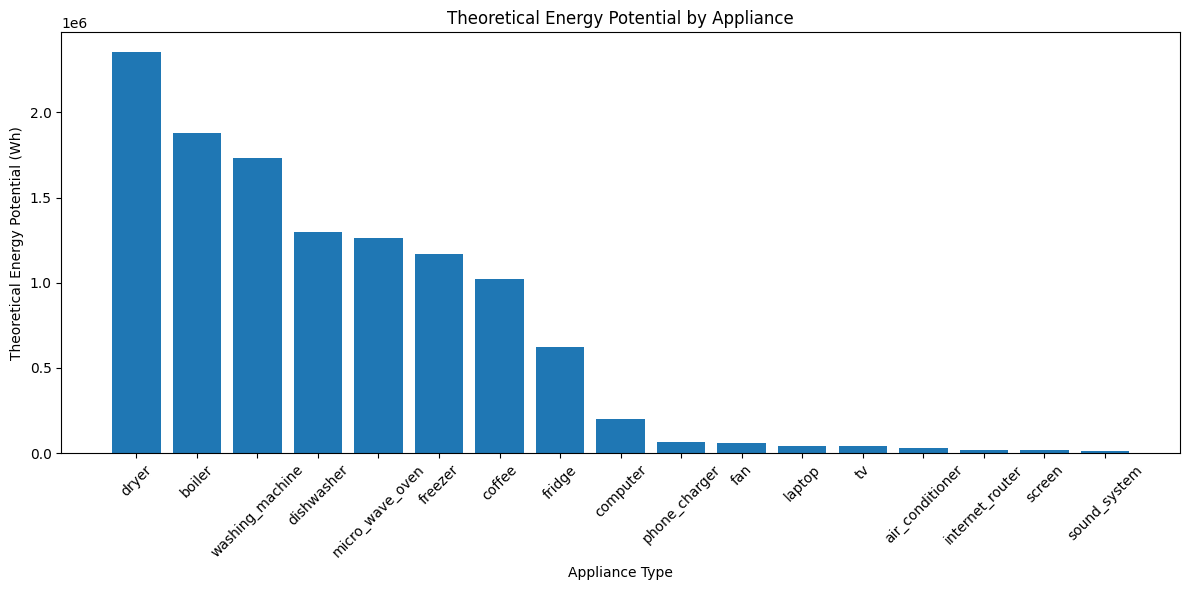

In [78]:
df3_energy_potential = df3.assign(
    theoretical_energy_Wh=df3["power_max"] * df3["available_duration"] * 24
)

potential_by_appliance = (
    df3_energy_potential
    .groupby("standardized_appliance_name")["theoretical_energy_Wh"]
    .mean()
    .sort_values(ascending=False)
)

print("Theoretical energy potential by appliance (Wh):")
print(potential_by_appliance)

plt.figure(figsize=(12, 6))
plt.bar(potential_by_appliance.index, potential_by_appliance.values)
plt.xlabel("Appliance Type")
plt.ylabel("Theoretical Energy Potential (Wh)")
plt.title("Theoretical Energy Potential by Appliance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Final EDA Insights
The following summary prints data-driven observations from the three datasets for use in the final project discussion.

In [79]:
print("=" * 70)
print("FINAL EDA INSIGHTS")
print("=" * 70)

print("\nDataset 1")
print("- Highest average-energy appliance:", appliance_mean.index[0], "->", round(appliance_mean.iloc[0], 3), "kWh")
print("- Highest average-energy season:", season_mean.idxmax(), "->", round(season_mean.max(), 3), "kWh")
print("- Highest average-energy household size:", household_mean.idxmax(), "->", round(household_mean.max(), 3), "kWh")
print("- Temperature-energy correlation:", round(df1["Outdoor Temperature (°C)"].corr(df1["Energy Consumption (kWh)"]), 4))
print("- Highest average-energy hour:", hourly_mean.idxmax(), "->", round(hourly_mean.max(), 3), "kWh")

print("\nDataset 2")
print("- Highest average-energy appliance:", appliance_mean2.index[0], "->", round(appliance_mean2.iloc[0], 3), "kWh")
print("- Highest average-energy occupancy status:", occupancy_mean.idxmax(), "->", round(occupancy_mean.max(), 3), "kWh")
print("- Highest average-energy season:", season_mean2.idxmax(), "->", round(season_mean2.max(), 3), "kWh")
print("- Temperature-setting correlation:", round(temperature_correlation, 4))
print("- Usage-duration/energy correlation:", round(df2["usage_duration_minutes"].corr(df2["energy_consumption_kWh"]), 4))
print("- Highest average-energy hour:", hourly_mean2.idxmax(), "->", round(hourly_mean2.max(), 3), "kWh")

print("\nDataset 3")
print("- Highest average-power appliance:", appliance_power_mean.index[0], "->", round(appliance_power_mean.iloc[0], 2), "W")
print("- Highest average-availability appliance:", availability_by_appliance.index[0], "->", round(availability_by_appliance.iloc[0], 2), "days")
print("- Number of standardized appliance types:", df3["standardized_appliance_name"].nunique())
print("- Number of appliance categories:", df3["appliance_category"].nunique())

print("\nThese findings can guide later feature engineering, prediction, clustering, or recommendation steps in the Smart Home Energy Advisor.")

FINAL EDA INSIGHTS

Dataset 1
- Highest average-energy appliance: Air Conditioning -> 3.5 kWh
- Highest average-energy season: Spring -> 1.511 kWh
- Highest average-energy household size: 2 -> 1.513 kWh
- Temperature-energy correlation: 0.002
- Highest average-energy hour: 14 -> 1.539 kWh

Dataset 2
- Highest average-energy appliance: Dishwasher -> 2.555 kWh
- Highest average-energy occupancy status: Occupied -> 2.55 kWh
- Highest average-energy season: Winter -> 2.552 kWh
- Temperature-setting correlation: -0.0003
- Usage-duration/energy correlation: 0.0005
- Highest average-energy hour: 5 -> 2.56 kWh

Dataset 3
- Highest average-power appliance: dryer -> 3267.0 W
- Highest average-availability appliance: air_conditioner -> 30.0 days
- Number of standardized appliance types: 17
- Number of appliance categories: 4

These findings can guide later feature engineering, prediction, clustering, or recommendation steps in the Smart Home Energy Advisor.


# preprocessing

# Dataset 1

 Smart Home Energy Consumption

Handling Missing

In [80]:
print("Missing values in df1:")
print(df1.isnull().sum())

Missing values in df1:
Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64


Handling Duplicates

In [81]:
print("Duplicates before:", df1.duplicated().sum())
df1 = df1.drop_duplicates()
print("Duplicates after:", df1.duplicated().sum())
print("Shape:", df1.shape)

Duplicates before: 0
Duplicates after: 0
Shape: (100000, 8)


Handling Outliers

In [82]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

In [83]:
outlier_mask = pd.Series(False, index=df1.index)
for appliance, group in df1.groupby("Appliance Type")["Energy Consumption (kWh)"]:
    lower, upper = iqr_bounds(group)
    outlier_mask.loc[group.index] = (group < lower) | (group > upper)

print(f"Per-appliance outliers: {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}%)")

Per-appliance outliers: 0 (0.00%)


In [84]:
def cap(group):
    lower, upper = iqr_bounds(group)
    return group.clip(lower, upper)

df1["Energy Consumption (kWh)"] = (
    df1.groupby("Appliance Type")["Energy Consumption (kWh)"].transform(cap)
)

Feature Engineering

In [85]:
df1["Hour"] = pd.to_datetime(df1["Time"], format="%H:%M").dt.hour
date_parsed = pd.to_datetime(df1["Date"])
df1["Month"] = date_parsed.dt.month
df1["DayOfWeek"] = date_parsed.dt.day_name()
df1["IsWeekend"] = (date_parsed.dt.dayofweek >= 5).astype(int)

df1 = df1.drop(columns=["Time", "Date"])

Categorical Encoding

In [86]:
df1 = pd.get_dummies(
    df1,
    columns=["Appliance Type", "Season", "DayOfWeek"],
    drop_first=True
)

Feature Selection + Train/Test Split

In [87]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

df1_model = df1.drop(columns=["Home ID"])

X1 = df1_model.drop(columns=["Energy Consumption (kWh)"])
y1 = df1_model["Energy Consumption (kWh)"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print("Train shape:", X1_train.shape, "Test shape:", X1_test.shape)

Train shape: (80000, 23) Test shape: (20000, 23)


Feature Scaling

In [88]:
from sklearn.preprocessing import StandardScaler

numeric_cols_1 = ["Outdoor Temperature (°C)", "Household Size", "Hour", "Month"]

scaler_1 = StandardScaler()
X1_train[numeric_cols_1] = scaler_1.fit_transform(X1_train[numeric_cols_1])
X1_test[numeric_cols_1] = scaler_1.transform(X1_test[numeric_cols_1])

Preventing Data Leakage

In [89]:
print("Scaler was fit on X1_train only.")
print("Train mean after scaling (should be ~0):", X1_train[numeric_cols_1].mean().round(3).to_dict())
print("Test mean after scaling (not necessarily 0 - this proves no leakage):",
      X1_test[numeric_cols_1].mean().round(3).to_dict())

Scaler was fit on X1_train only.
Train mean after scaling (should be ~0): {'Outdoor Temperature (°C)': 0.0, 'Household Size': -0.0, 'Hour': 0.0, 'Month': 0.0}
Test mean after scaling (not necessarily 0 - this proves no leakage): {'Outdoor Temperature (°C)': -0.01, 'Household Size': 0.0, 'Hour': 0.011, 'Month': 0.008}


# Dataset 2

Smart Home Energy Usage

Handling Missing Values

In [90]:
print("Missing values in df2:")
print(df2.isnull().sum())

Missing values in df2:
timestamp                 0
home_id                   0
energy_consumption_kWh    0
temperature_setting_C     0
occupancy_status          0
appliance                 0
usage_duration_minutes    0
season                    0
day_of_week               0
holiday                   0
dtype: int64


Handling Duplicates

In [91]:
print("Duplicates before:", df2.duplicated().sum())
df2 = df2.drop_duplicates()
print("Duplicates after:", df2.duplicated().sum())
print("Shape:", df2.shape)

Duplicates before: 0
Duplicates after: 0
Shape: (1000000, 10)


Handling Outliers

In [92]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

In [93]:
outlier_mask2 = pd.Series(False, index=df2.index)
for appliance, group in df2.groupby("appliance")["energy_consumption_kWh"]:
    lower, upper = iqr_bounds(group)
    outlier_mask2.loc[group.index] = (group < lower) | (group > upper)

print(f"Per-appliance outliers: {outlier_mask2.sum()} ({outlier_mask2.mean()*100:.4f}%)")

Per-appliance outliers: 0 (0.0000%)


Feature Engineering

In [94]:
ts = pd.to_datetime(df2["timestamp"])
df2["Hour"] = ts.dt.hour
df2["Month"] = ts.dt.month
df2["IsWeekend"] = (ts.dt.dayofweek >= 5).astype(int)

df2 = df2.drop(columns=["timestamp"])

Categorical Encoding

In [95]:
df2["occupancy_status"] = df2["occupancy_status"].map(
    {"Occupied": 1, "Unoccupied": 0}
)

df2 = pd.get_dummies(
    df2,
    columns=["appliance", "season", "day_of_week"],
    drop_first=True
)

Feature Selection + Train/Test Split

In [96]:
from sklearn.model_selection import train_test_split

df2_model = df2.drop(columns=["home_id"])

X2 = df2_model.drop(columns=["energy_consumption_kWh"])
y2 = df2_model["energy_consumption_kWh"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print("Train shape:", X2_train.shape, "Test shape:", X2_test.shape)

Train shape: (800000, 21) Test shape: (200000, 21)


Feature Scaling

In [97]:
from sklearn.preprocessing import StandardScaler

numeric_cols_2 = ["temperature_setting_C", "usage_duration_minutes", "Hour", "Month"]

scaler_2 = StandardScaler()
X2_train[numeric_cols_2] = scaler_2.fit_transform(X2_train[numeric_cols_2])
X2_test[numeric_cols_2] = scaler_2.transform(X2_test[numeric_cols_2])

Preventing Data Leakage

In [98]:
print("Train mean after scaling (should be ~0):",
      X2_train[numeric_cols_2].mean().round(3).to_dict())
print("Test mean after scaling (not exactly 0 - confirms no leakage):",
      X2_test[numeric_cols_2].mean().round(3).to_dict())

Train mean after scaling (should be ~0): {'temperature_setting_C': -0.0, 'usage_duration_minutes': -0.0, 'Hour': 0.0, 'Month': -0.0}
Test mean after scaling (not exactly 0 - confirms no leakage): {'temperature_setting_C': 0.001, 'usage_duration_minutes': -0.005, 'Hour': -0.002, 'Month': 0.002}


# Dataset 3

Household Appliances Metadata

Handling Missing Values

In [99]:
print("Missing values in df3:")
print(df3.isnull().sum())

df3 = df3.drop(columns=["comment"])

Missing values in df3:
id                              0
first_ts                        0
last_ts                         0
available_duration              0
plug_name                       0
standardized_appliance_name     0
appliance_category              0
comment                        13
files_names                     0
power_max                       0
dtype: int64


Handling Duplicates

In [100]:
print("Duplicates before:", df3.duplicated().sum())
df3 = df3.drop_duplicates()
print("Duplicates after:", df3.duplicated().sum())
print("Shape:", df3.shape)

Duplicates before: 0
Duplicates after: 0
Shape: (33, 9)


Handling Outliers

In [101]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["power_max", "available_duration"]:
    lower, upper = iqr_bounds(df3[col])
    n_out = ((df3[col] < lower) | (df3[col] > upper)).sum()
    print(f"{col}: {n_out} potential outliers")

power_max: 0 potential outliers
available_duration: 4 potential outliers


Feature Selection

In [102]:
df3 = df3.drop(columns=["id", "first_ts", "last_ts", "plug_name", "files_names"], errors='ignore')

In [103]:
df3 = pd.get_dummies(
    df3,
    columns=["standardized_appliance_name", "appliance_category"],
    drop_first=True
)

***Feature Scaling***

Best baseline model: Linear Regression (R2 = 0.7575)
Augmented Model Results:
                         MAE      RMSE        R2
Linear Regression  0.475984  0.583974  0.757542
Random Forest      0.476267  0.584930  0.756748
XGBoost            0.476415  0.585176  0.756543
Gradient Boosting  0.476046  0.584093  0.757443
Baseline vs Augmented:
                    Baseline R2  Augmented R2  R2 Change
Linear Regression     0.757542      0.757542   0.000000
Random Forest         0.756897      0.756748  -0.000149
XGBoost               0.646295      0.756543   0.110248
Gradient Boosting     0.537733      0.757443   0.219710
Final Model: Linear Regression
MAE : 0.476
RMSE: 0.584
R2  : 0.7575


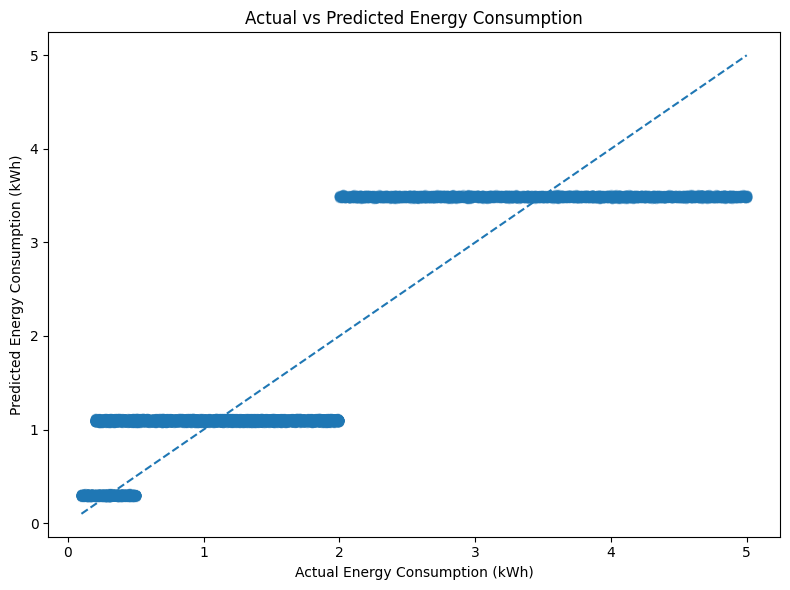

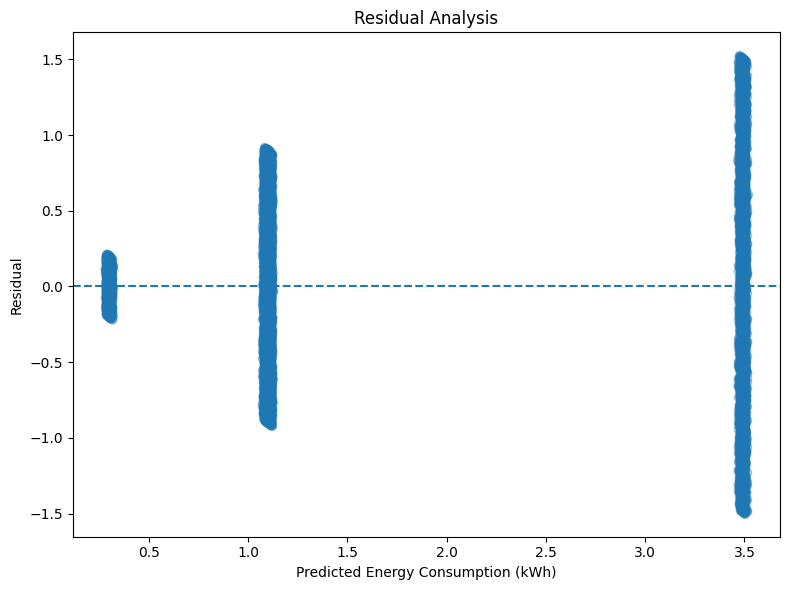

Most Influential Features:
                            Feature  Coefficient  Absolute_Coefficient
12               Appliance Type_TV    -2.385942              2.385942
5          Appliance Type_Computer    -2.032740              2.032740
7            Appliance Type_Fridge    -1.916735              1.916735
8            Appliance Type_Heater     1.511736              1.511736
23                       power_max    -1.177230              1.177230
9            Appliance Type_Lights    -0.882915              0.882915
11             Appliance Type_Oven    -0.872570              0.872570
24              available_duration    -0.367618              0.367618
6        Appliance Type_Dishwasher     0.359052              0.359052
10        Appliance Type_Microwave     0.285034              0.285034
25        Auxiliary_Data_Available     0.243749              0.243749
13  Appliance Type_Washing Machine     0.110389              0.110389
16                   Season_Winter    -0.041459              0

In [104]:
# ================= Feature Scaling =================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

numeric_cols_3 = ["power_max", "available_duration"]
scaler_3 = StandardScaler()
df3[numeric_cols_3] = scaler_3.fit_transform(df3[numeric_cols_3])


# ================= Helper: build & evaluate models (Fast Version) =================
def get_models():
    return {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=50, max_depth=10, n_jobs=-1, random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=50, max_depth=5, learning_rate=0.1,
            objective="reg:squarederror", n_jobs=-1, random_state=42
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42
        ),
    }


def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = {}
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results[name] = {
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds),
        }
        fitted[name] = model
    return pd.DataFrame(results).T, fitted


# ================= Baseline models (Dataset 1 only) =================
results_df, fitted_models = evaluate_models(get_models(), X1_train, y1_train, X1_test, y1_test)
best_name = results_df["R2"].idxmax()
print(f"Best baseline model: {best_name} (R2 = {results_df.loc[best_name, 'R2']:.4f})")


# ================= Build auxiliary features from Dataset 3 =================
appliance_mapping = {
    "Fridge": "fridge",
    "Dishwasher": "dishwasher",
    "Microwave": "micro_wave_oven",
    "Air Conditioning": "air_conditioner",
    "Computer": "computer",
    "TV": "tv",
    "Washing Machine": "washing_machine",
}

df1_aux = df1_original.copy()
df1_aux["appliance_metadata"] = df1_aux["Appliance Type"].map(appliance_mapping)

df3_aux = (
    df3_original[["standardized_appliance_name", "appliance_category", "power_max", "available_duration"]]
    .groupby("standardized_appliance_name", as_index=False)
    .agg({"power_max": "mean", "available_duration": "mean"})
    .rename(columns={"standardized_appliance_name": "appliance_metadata"})
)

aux_features = df1_aux[["appliance_metadata"]].merge(df3_aux, on="appliance_metadata", how="left")
aux_features["Auxiliary_Data_Available"] = aux_features["power_max"].notna().astype(int)
aux_features["power_max"] = aux_features["power_max"].fillna(aux_features["power_max"].median())
aux_features["available_duration"] = aux_features["available_duration"].fillna(aux_features["available_duration"].median())

X1_augmented = X1.copy()
X1_augmented[["power_max", "available_duration", "Auxiliary_Data_Available"]] = aux_features[
    ["power_max", "available_duration", "Auxiliary_Data_Available"]
].values


# ================= Train/test split + scale augmented features =================
X1_aug_train, X1_aug_test, y1_aug_train, y1_aug_test = train_test_split(
    X1_augmented, y1, test_size=0.2, random_state=42
)

aux_numeric_cols = ["power_max", "available_duration"]
scaler_aux = StandardScaler()
X1_aug_train[aux_numeric_cols] = scaler_aux.fit_transform(X1_aug_train[aux_numeric_cols])
X1_aug_test[aux_numeric_cols] = scaler_aux.transform(X1_aug_test[aux_numeric_cols])


# ================= Augmented models =================
augmented_results_df, fitted_augmented_models = evaluate_models(
    get_models(), X1_aug_train, y1_aug_train, X1_aug_test, y1_aug_test
)
print("Augmented Model Results:\n", augmented_results_df)


# ================= Baseline vs Augmented comparison =================
comparison_df = pd.DataFrame({
    "Baseline R2": results_df["R2"],
    "Augmented R2": augmented_results_df["R2"],
})
comparison_df["R2 Change"] = comparison_df["Augmented R2"] - comparison_df["Baseline R2"]
print("Baseline vs Augmented:\n", comparison_df)


# ================= Final model (reuse already-fitted Linear Regression) =================
final_model = fitted_augmented_models["Linear Regression"]
final_predictions = final_model.predict(X1_aug_test)

print("Final Model: Linear Regression")
print("MAE :", round(mean_absolute_error(y1_aug_test, final_predictions), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y1_aug_test, final_predictions)), 4))
print("R2  :", round(r2_score(y1_aug_test, final_predictions), 4))


# ================= Actual vs Predicted =================
plt.figure(figsize=(8, 6))
plt.scatter(y1_aug_test, final_predictions, alpha=0.3)
plt.plot([y1_aug_test.min(), y1_aug_test.max()], [y1_aug_test.min(), y1_aug_test.max()], linestyle="--")
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.tight_layout()
plt.show()


# ================= Residual Analysis =================
residuals = y1_aug_test - final_predictions
plt.figure(figsize=(8, 6))
plt.scatter(final_predictions, residuals, alpha=0.3)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Energy Consumption (kWh)")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.tight_layout()
plt.show()


# ================= Feature Coefficients =================
feature_coefficients = pd.DataFrame({
    "Feature": X1_aug_train.columns,
    "Coefficient": final_model.coef_,
})
feature_coefficients["Absolute_Coefficient"] = feature_coefficients["Coefficient"].abs()
feature_coefficients = feature_coefficients.sort_values("Absolute_Coefficient", ascending=False)
print("Most Influential Features:\n", feature_coefficients.head(15))

## **Best Model**

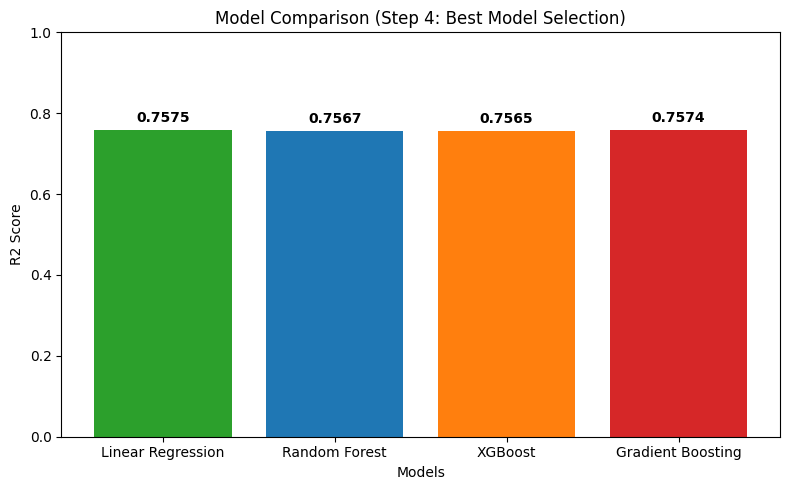

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(augmented_results_df.index, augmented_results_df["R2"], color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (Step 4: Best Model Selection)")
plt.ylim(0, 1)

for i, v in enumerate(augmented_results_df["R2"]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## **Predicted Energy Consumption**

In [113]:
best_model = final_model
sample_user_input = X1_aug_test.iloc[[0]]
predicted_kwh = float(best_model.predict(sample_user_input)[0])
print(f"Predicted Energy Consumption: {round(predicted_kwh, 2)} kWh")

Predicted Energy Consumption: 1.11 kWh


## **Egyptian Elictricity Tariff Calculator**

In [114]:
def calculate_egyptian_tariff(kwh):
    if kwh <= 50:
        bill = kwh * 0.68
    elif kwh <= 100:
        bill = (50 * 0.68) + ((kwh - 50) * 0.78)
    elif kwh <= 200:
        bill = kwh * 0.95
    elif kwh <= 350:
        bill = (200 * 0.95) + ((kwh - 200) * 1.55)
    elif kwh <= 650:
        bill = (200 * 0.95) + (150 * 1.55) + ((kwh - 350) * 1.95)
    elif kwh <= 1000:
        bill = kwh * 2.10
    else:
        bill = kwh * 2.23

    return round(bill, 2)

## **Budget Evaluator**

In [132]:
def evaluate_budget(estimated_bill, user_budget, num_persons=1):
    diff = estimated_bill - user_budget
    percentage = (estimated_bill / user_budget) * 100

    bill_per_person = round(estimated_bill / num_persons, 2)
    budget_per_person = round(user_budget / num_persons, 2)

    lower_bound_bill = user_budget * 0.90
    upper_bound_bill = user_budget * 1.10

    if estimated_bill < lower_bound_bill:
        bill_check = "Within Budget"
    elif lower_bound_bill <= estimated_bill <= upper_bound_bill:
        bill_check = "Close to Budget"
    else:
        bill_check = "Over Budget"

    if percentage < 90.0:
        final_status = "Within Budget"
        message = f"Optimal consumption ({round(percentage, 1)}% of budget). Surplus: {abs(round(diff, 2))} EGP."
    elif 90.0 <= percentage <= 110.0:
        final_status = "Close to Budget"
        if diff <= 0:
            message = f"Warning: You are close to your budget limit ({round(percentage, 1)}% of budget). Remaining surplus: {abs(round(diff, 2))} EGP."
        else:
            message = f"Warning: Slightly over budget ({round(percentage, 1)}% of budget) by {round(diff, 2)} EGP."
    else:
        final_status = "Over Budget"
        message = f"Alert: Significantly over budget ({round(percentage, 1)}% of budget) by {round(diff, 2)} EGP!"

    return final_status, message, bill_per_person

## **Recommendations & What-if Scenario Engine**

In [128]:
def generate_recommendations(predicted_kwh, estimated_bill, user_budget, top_appliance="Fridge"):
    if not top_appliance:
        top_appliance = "Air Conditioner"

    percentage = (estimated_bill / user_budget) * 100
    recs = []

    if percentage >= 90.0:
        recs.append(f"It appears that the ({top_appliance}) is a major contributor to your high consumption.")
        recs.append("It is recommended to reduce unnecessary operating hours or adjust to energy-saving settings.")
        recs.append("Ensure appliances are not left on Standby Mode when not in use.")

        reduced_kwh = predicted_kwh * 0.85
        new_bill = calculate_egyptian_tariff(reduced_kwh)
        savings = estimated_bill - new_bill

        what_if = (
            f"If you optimize the usage of {top_appliance} and slightly reduce operation, "
            f"your bill will decrease to {new_bill} EGP (saving {round(savings, 2)} EGP)."
        )

    else:
        recs.append("Your energy consumption is well-optimized and within your safe budget limit.")
        recs.append("No immediate action is required. Keep maintaining your current usage patterns!")

        what_if = "Your budget is fully safe under current consumption levels. No optimized scenario needed."

    return recs, what_if

## **Master Pipeline & Payload Builder**

In [129]:
def run_smart_home_advisor(user_input_data, trained_model, model_name, model_accuracy, user_budget, num_persons=1, top_appliance=None):
    # Step 5: Hourly Predicted Energy Consumption (kWh)
    hourly_kwh = float(trained_model.predict(user_input_data)[0])

    # Scale up hourly prediction to full monthly consumption (24 hours * 30 days)
    predicted_kwh = hourly_kwh * 24 * 30

    # Steps 6 & 7: Calculate Tariff & Bill based on Monthly kWh
    estimated_bill = calculate_egyptian_tariff(predicted_kwh)

    # Budget Evaluation with number of persons
    budget_status, budget_msg, bill_per_person = evaluate_budget(estimated_bill, user_budget, num_persons)

    # Recommendations & What-if scenario
    recommendations, what_if = generate_recommendations(predicted_kwh, estimated_bill, user_budget, top_appliance)

    payload = {
        "best_model_name": model_name,
        "accuracy_r2": model_accuracy,
        "number_of_residents": num_persons,
        "predicted_kwh": round(predicted_kwh, 2),
        "estimated_bill": estimated_bill,
        "cost_per_person": bill_per_person,
        "budget_status": budget_status,
        "budget_message": budget_msg,
        "recommendations": recommendations,
        "what_if_scenario": what_if
    }

    return payload